<b><font size="6" color="#E8800A">Homework · Repeat purchase within 90 days</font></b><br>
<b><font size="4">Machine Learning · Group XX · Everything &amp; Then Some repeat-purchase data</font></b><br>

This notebook follows the task list of the homework. **Section 1, Import and
explore the data**, is below. It inspects `train.csv` and `clientes.csv`,
describes the observations and variables, reports descriptive statistics, checks
data quality and inconsistencies, and explores univariate and multivariate
relationships.

Section 1 only looks. No cell changes `train` or `clientes`, and every problem
found is carried to Section 2 as an open decision in the closing table.

<div class="alert alert-block alert-info">

# TOC<a class="anchor" id="toc"></a>
* [<font color='#E8800A'>1 · Import and explore the data</font>](#explore)
    * [<font color='#E8800A'>1.1 · The prediction problem</font>](#framing)
    * [<font color='#E8800A'>1.2 · Libraries and data import</font>](#import)
    * [<font color='#E8800A'>1.3 · Observations and variables</font>](#survey)
    * [<font color='#E8800A'>1.4 · Repeated rows and repeated customers</font>](#duplicates)
    * [<font color='#E8800A'>1.5 · The target</font>](#target)
    * [<font color='#E8800A'>1.6 · Missing values</font>](#missing)
    * [<font color='#E8800A'>1.7 · Descriptive statistics and distributions</font>](#distributions)
    * [<font color='#E8800A'>1.8 · Impossible values and inconsistencies</font>](#invalid)
    * [<font color='#E8800A'>1.9 · Categorical variables</font>](#categorical)
    * [<font color='#E8800A'>1.10 · The customer table, clientes.csv</font>](#clientes)
    * [<font color='#E8800A'>1.11 · Relationships with the target and between features</font>](#relationships)
    * [<font color='#E8800A'>1.12 · What the exploration found</font>](#findings)

</div>

# <font color='#E8800A'>1 · Import and explore the data</font> <a class="anchor" id="explore"></a>

## <font color='#E8800A'>1.1 · The prediction problem</font> <a class="anchor" id="framing"></a>
[Back to TOC](#toc)

Before any statistic, the five objects of the supervised problem. They decide
which columns are legitimate features and which score means anything.

| object | in this homework |
|---|---|
| **observation** | one purchase of one customer on one date (one row of `train.csv`) |
| **features** | what is known when that purchase is invoiced: the purchase itself, the customer's history up to it, and the customer's record in `clientes.csv` |
| **target** | `repeat_purchase_90d`: 1 if the same customer buys again within 90 days, 0 if not |
| **prediction moment** | right after the purchase, before the next 90 days have happened |
| **decision** | which customers to follow up with (our assumption; the brief does not name one) |

The task is **binary classification**. The prediction moment gives the check
that matters most in this section: a feature that already contains information
from after the purchase would be leakage.

## <font color='#E8800A'>1.2 · Libraries and data import</font> <a class="anchor" id="import"></a>
[Back to TOC](#toc)

`pandas` and `numpy` for the tables, `matplotlib` and `seaborn` for the plots,
`scipy` for the association measures used in class, and `train_test_split` to
set aside an exploration part before any feature is read against the label.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from scipy.stats.contingency import association
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
PLOT_BLUE, PLOT_ORANGE = "#1779A8", "#C96A00"  # course plot colours
FIGSIZE = (11, 4.5)

DATA_DIR = Path(".")  # folder holding train.csv and clientes.csv
TARGET = "repeat_purchase_90d"

Both files are read from `DATA_DIR`, the folder of this notebook. `ID` goes into
the index: it identifies a row and must stay unchanged for the submission, and
in the index it cannot be handed to a model by accident. `purchase_date` is
parsed as a date on reading.

In [2]:
# `ID` identifies the row, so it goes in the index rather than sitting among
# the columns a model could be handed by accident.
train = pd.read_csv(DATA_DIR / "train.csv", index_col="ID", parse_dates=["purchase_date"])
clientes = pd.read_csv(DATA_DIR / "clientes.csv")

print(f"train.csv   : {train.shape[0]:,} rows x {train.shape[1]} columns, indexed by ID")
print(f"clientes.csv: {clientes.shape[0]:,} rows x {clientes.shape[1]} columns")
train.head()

train.csv   : 6,534 rows x 38 columns, indexed by ID
clientes.csv: 1,143 rows x 13 columns


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,repeat_purchase_90d,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,random_noise
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10000000,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,1,79.0,126.0,2.0,858.30,429.150000,112.656252,349.49,508.81,47.000000,NaN,0.0,0.00,1.0,349.49,2.0,858.30,2.0,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,-0.660448
10000001,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,1,244.0,616.0,5.0,6722.83,1344.566000,1683.795178,84.38,4222.15,93.000000,117.657696,0.0,0.00,0.0,0.00,0.0,0.00,4.0,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,0.924510
10000002,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,1,9.0,610.0,90.0,17590.08,195.445333,190.389932,4.54,1002.15,6.752809,6.384073,2.0,111.27,9.0,1928.55,28.0,5290.25,49.0,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,-0.258730
10000003,856.83,696.61,696.61,160.22,0.0,0.0,0.00,408.167275,9.0,1.0,0,97.0,97.0,1.0,270.33,270.330000,NaN,270.33,270.33,NaN,NaN,0.0,0.00,0.0,0.00,1.0,270.33,1.0,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,1.448402
10000004,1616.10,1488.85,1313.90,302.20,0.0,0.0,174.95,485.401864,33.0,1.0,1,85.0,1575.0,25.0,12803.02,512.120800,406.696963,22.58,1736.74,62.083333,66.246520,0.0,0.00,2.0,184.13,4.0,2062.50,4.0,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,-1.058890


## <font color='#E8800A'>1.3 · Observations and variables</font> <a class="anchor" id="survey"></a>
[Back to TOC](#toc)

__Step 1:__ Sort the columns by what they hold. A dtype says how a value is
stored, not what it measures, so each column gets a role, and the rest of the
section applies different checks to each group.

In [3]:
# Sort every column into a role by what it MEASURES. Nothing below treats a
# group it did not name.
identifiers = ["customer_id"]
basket = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Total Portes",
          "Total Desc_ Global", "Total Desc_ Linha", "Custo", "N_ Detalhes",
          "invoice_count_current_purchase"]
history = ["days_since_previous_purchase", "customer_tenure_days", "prior_purchase_count",
           "prior_total_spend", "prior_mean_purchase_value", "prior_std_purchase_value",
           "prior_min_purchase_value", "prior_max_purchase_value",
           "prior_mean_gap_days", "prior_std_gap_days"]
windows = [f"{kind}_{days}d" for days in (30, 90, 180, 365)
           for kind in ("purchase_count", "spend")]
categorical = ["payment_type", "salesperson", "commercial_zone", "transport_method",
               "warehouse", "document_series"]
other = ["purchase_date", "random_noise"]

numeric = basket + history + windows
features = numeric + categorical + other

roles = {**dict.fromkeys(identifiers, "identifier"), TARGET: "target",
         **dict.fromkeys(basket, "current purchase"),
         **dict.fromkeys(history, "customer history"),
         **dict.fromkeys(windows, "recent-activity window"),
         **dict.fromkeys(categorical, "categorical"),
         "purchase_date": "date", "random_noise": "unexplained numeric"}
assert set(roles) == set(train.columns), "every column needs exactly one role"

survey = pd.DataFrame({
    "role": pd.Series(roles),
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing %": (100 * train.isna().mean()).round(2),
    "distinct": train.nunique(),
    "example": train.iloc[0].astype(str).str.slice(0, 28),
}).loc[list(train.columns)]
survey

,role,dtype,missing,missing %,distinct,example
Total a Pagar,current purchase,float64,65,0.99,6122,558.11
Total Bruto,current purchase,float64,65,0.99,6038,510.9
Total Liquido,current purchase,float64,65,0.99,6093,453.75
Total Imp_,current purchase,float64,65,0.99,5406,104.36
Total Portes,current purchase,float64,65,0.99,215,0.0
Total Desc_ Global,current purchase,float64,65,0.99,109,0.0
Total Desc_ Linha,current purchase,float64,65,0.99,3519,57.15
Custo,current purchase,float64,65,0.99,5736,153.09991100000002
N_ Detalhes,current purchase,float64,65,0.99,171,4.0
invoice_count_current_purchase,current purchase,float64,65,0.99,5,1.0


**6,534 purchases described by 38 columns**: the target, one identifier
(`customer_id`), 28 numeric measurements, 6 categorical columns, a date and one
column called `random_noise`.

| group | columns | what they describe |
|---|---|---|
| **current purchase** (10) | `Total a Pagar`, `Total Bruto`, `Total Liquido`, `Total Imp_`, `Total Portes`, `Total Desc_ Global`, `Total Desc_ Linha`, `Custo`, `N_ Detalhes`, `invoice_count_current_purchase` | the invoice: amount payable, gross and net amount, tax, shipping, global and line discounts, cost, number of invoice lines, number of invoices |
| **customer history** (10) | `days_since_previous_purchase`, `customer_tenure_days`, `prior_*` | everything the customer did before this purchase: how many purchases, total, mean, spread, smallest and largest value, and the gaps between them |
| **recent-activity windows** (8) | `purchase_count_*d`, `spend_*d` for 30, 90, 180 and 365 days | the same history restricted to the days just before the purchase |
| **categorical** (6) | `payment_type`, `salesperson`, `commercial_zone`, `transport_method`, `warehouse`, `document_series` | how the sale was handled |
| **other** | `purchase_date`, `random_noise` | when the purchase happened; a number with no stated meaning |

The meaning of the Portuguese invoice columns is read from their names, and
Section 1.8 confirms it with the accounting identities between them.

`customer_id` is stored as an integer, but it is a label: 610 distinct values
on 6,534 rows. Its numeric size means nothing, so it is kept out of `numeric`.

__Step 2:__ Which columns behave like identifiers? A column that is distinct on
almost every row identifies the row, not a property of it.

In [4]:
# A column distinct on (almost) every row identifies the row, not a property
# of it. `ID` is already in the index; which of the remaining columns behave
# the same way?
distinct_share = (train.nunique() / train.notna().sum()).sort_values(ascending=False)
print("share of non-missing rows carrying a distinct value (top 8):")
print(distinct_share.head(8).round(3).to_string())

print(f"\nID: unique = {train.index.is_unique}, range {train.index.min():,} to {train.index.max():,},"
      f" {train.index.max() - train.index.min() + 1 - len(train):,} IDs inside the range are not in train.csv")

share of non-missing rows carrying a distinct value (top 8):
random_noise                 1.000
prior_std_purchase_value     1.000
prior_mean_purchase_value    0.996
prior_std_gap_days           0.971
Total a Pagar                0.946
Total Liquido                0.942
Total Bruto                  0.933
prior_total_spend            0.906

ID: unique = True, range 10,000,000 to 10,007,674, 1,141 IDs inside the range are not in train.csv


**`random_noise` is distinct on every row** and, unlike the amounts beside it in
that list, nothing in the file says what it measures. Money amounts are
naturally near-unique, so the list alone does not condemn them; a column that
is unique *and* unexplained is treated as a suspected identifier-like variable
and tested against the target in Section 1.11 before anything is decided.

**`ID` is unique and runs from 10,000,000 to 10,007,674, with 1,141 values in
that range absent from `train.csv`.** Those are presumably the rows of
`test.csv`, which would mean the two files were cut from one table at random
positions rather than by date. `test.csv` is not opened in this section.

## <font color='#E8800A'>1.4 · Repeated rows and repeated customers</font> <a class="anchor" id="duplicates"></a>
[Back to TOC](#toc)

__Step 3:__ Count repetition at two levels before computing anything else.
Every statistic below is a count or a sum over rows, so a row that appears
twice is counted twice.

In [5]:
# `ID` is in the index, so `.duplicated()` already ignores it.
duplicate_rows = train.duplicated(keep=False)
print("rows that are exact copies of another row (ignoring ID):", duplicate_rows.sum())

# What do the copies look like?
empty_row = train[features].isna().all(axis=1)
print(f"rows with EVERY feature missing: {empty_row.sum()}"
      f" ({100 * empty_row.mean():.2f}% of the file)")
print("duplicated rows that are such empty rows:", (duplicate_rows & empty_row).sum())
print("columns still filled in on an empty row:",
      list(train.columns[train[empty_row].notna().all()]))

# The repetition one level up: is one row one customer?
per_customer = train.groupby("customer_id").size()
print(f"\n{train['customer_id'].nunique()} customers for {len(train):,} rows")
print(per_customer.describe().round(1).to_string())
print("\nsame customer on the same date more than once:",
      train[~empty_row].duplicated(["customer_id", "purchase_date"]).sum())

rows that are exact copies of another row (ignoring ID): 16
rows with EVERY feature missing: 65 (0.99% of the file)
duplicated rows that are such empty rows: 16
columns still filled in on an empty row: ['repeat_purchase_90d', 'customer_id']

610 customers for 6,534 rows
count    610.0
mean      10.7
std       20.0
min        1.0
25%        1.0
50%        4.0
75%       12.0
max      277.0

same customer on the same date more than once: 0


**16 rows are exact copies of another row, and all 16 are rows with no feature
at all.** They are not repeated purchases. They belong to a larger group:
**65 rows (0.99%) carry only an `ID`, a `customer_id` and a label**, with all
36 feature columns empty. Two such rows of the same customer with the same
label are indistinguishable, which is the only reason they register as
duplicates. Among the rows that do carry features there is no duplicate, and no
customer appears twice on the same date.

**The real repetition is one level up: 6,534 rows belong to 610 customers.**
The median customer has 4 rows, the mean is 10.7 and one customer has 277.

In [6]:
# A VIEW for the statistics below, not a cleaning decision: the rows that carry
# at least one feature. `train` itself is not modified anywhere in this section.
filled = train[~empty_row]
print(f"{len(filled):,} rows carry features; {empty_row.sum()} carry only an ID, a customer and a label")
print(f"repeat rate on the empty rows: {train.loc[empty_row, TARGET].mean():.3f}"
      f"   on the others: {filled[TARGET].mean():.3f}")

6,469 rows carry features; 65 carry only an ID, a customer and a label
repeat rate on the empty rows: 0.508   on the others: 0.560


The statistics from here on are computed on `filled`, the 6,469 rows that have
features, because a row with nothing in it has no distribution to describe.
This is a view for exploring, and what to do with the 65 rows is left open:
their repeat rate (0.508) is below that of the other rows (0.560), and
`test.csv` may contain rows like them that still need a prediction.

customers with a single row: 157 of 610
largest customer: 277 rows (4.2% of the file)
top 10 customers (2%): 17.5% of rows
top 61 customers (10%): 50.4% of rows


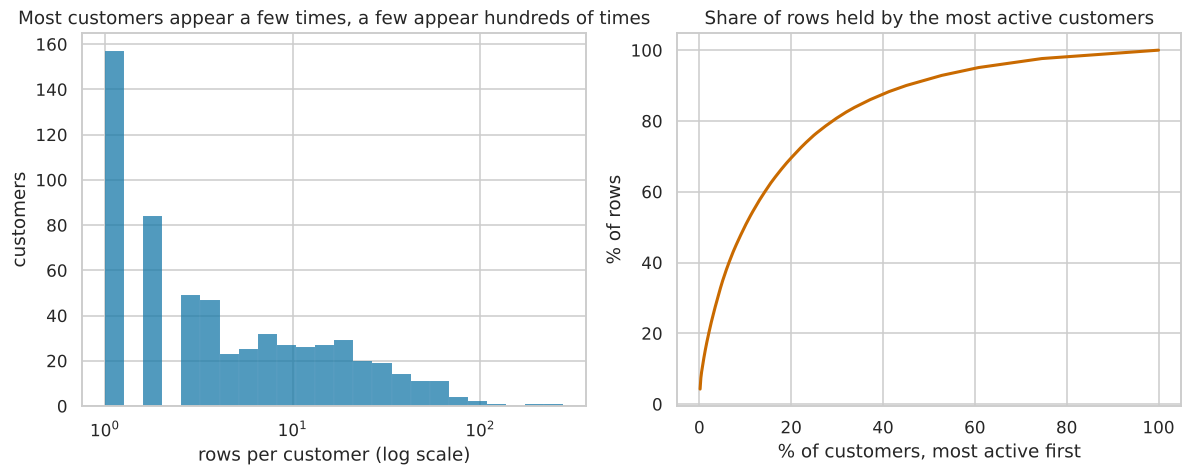

In [7]:
ranked = per_customer.sort_values(ascending=False)
cumulative = ranked.cumsum() / ranked.sum()

fig, (left, right) = plt.subplots(1, 2, figsize=FIGSIZE)
sns.histplot(per_customer, bins=np.logspace(0, np.log10(per_customer.max()), 25),
             color=PLOT_BLUE, ax=left)
left.set(xscale="log", xlabel="rows per customer (log scale)", ylabel="customers",
         title="Most customers appear a few times, a few appear hundreds of times")
right.plot(np.arange(1, len(cumulative) + 1) / len(cumulative) * 100, cumulative * 100,
           color=PLOT_ORANGE, lw=2)
right.set(xlabel="% of customers, most active first", ylabel="% of rows",
          title="Share of rows held by the most active customers")
plt.tight_layout()
plt.show()

print(f"customers with a single row: {(per_customer == 1).sum()} of {len(per_customer)}")
print(f"largest customer: {ranked.iloc[0]} rows ({100 * ranked.iloc[0] / len(train):.1f}% of the file)")
for top in (10, 61):
    print(f"top {top:>2} customers ({100 * top / len(per_customer):.0f}%): {100 * cumulative.iloc[top - 1]:.1f}% of rows")

**The file is dominated by a few very active customers.** 157 of the 610
customers appear once, while the 10 most active hold 17.5% of the rows and the
top 10% (61 customers) hold 50.4%.

Two consequences. Rows of the same customer are not independent observations,
so a random split puts the same customer on both sides and the assessment in
Section 4 has to take that into account. And any pattern in the file is
weighted towards how a few dozen large customers behave.

## <font color='#E8800A'>1.5 · The target</font> <a class="anchor" id="target"></a>
[Back to TOC](#toc)

__Step 4:__ Look at the target on its own before looking at anything against
it. Which score to report depends on this one number.

In [8]:
balance = train[TARGET].value_counts().sort_index()
print(balance.to_frame("rows").assign(
    share=lambda f: (f["rows"] / len(train)).round(4)).to_string())

# The floor any classifier clears by refusing to think: always answer with
# whichever class is larger.
print(f"\nalways predicting the majority class scores"
      f" {balance.max() / balance.sum():.4f} accuracy")

                     rows   share
repeat_purchase_90d              
0                    2880  0.4408
1                    3654  0.5592

always predicting the majority class scores 0.5592 accuracy


**3,654 purchases were followed by another within 90 days and 2,880 were not: a
55.92% majority.** The classes are close to balanced, so accuracy is readable,
but a model that answers "repeat" every time already scores **0.5592**. That is
the floor every later result is read against.

__Step 5:__ Check where the label comes from. If it means "bought again within
90 days", the same customer's next row should reproduce it.

In [9]:
# Where does the label come from? If it means "this customer bought again
# within 90 days", the next purchase of the same customer should reproduce it.
ordered = filled.sort_values(["customer_id", "purchase_date"])
next_date = ordered.groupby("customer_id")["purchase_date"].shift(-1)
gap_to_next = (next_date - ordered["purchase_date"]).dt.days

seen_within_90 = gap_to_next <= 90
check = pd.DataFrame({
    "rows": [seen_within_90.sum(), (~seen_within_90).sum()],
    "repeat rate": [ordered.loc[seen_within_90, TARGET].mean(),
                    ordered.loc[~seen_within_90, TARGET].mean()],
}, index=["next purchase in train.csv within 90 days",
          "no such purchase in train.csv"])
check.round(4)

,rows,repeat rate
next purchase in train.csv within 90 days,3565,1.0000
no such purchase in train.csv,2904,0.0193


**The label is exactly what its name says.** For 3,565 rows the customer's next
purchase is in `train.csv` and falls within 90 days, and every one of them is
labelled 1. Of the 2,904 rows with no such purchase in the file, only 1.93%
(56 rows) are labelled 1, which is what we would expect if the following
purchase sits in the rows that are not in `train.csv`.

So the label is clean, and it is computed from the customer's *next* purchase.
That makes the neighbouring rows of a customer informative about each other,
which is one more reason to keep features strictly to what the row itself
knew at the time.

In [10]:
# Do the history and window columns stop BEFORE the current purchase? On a
# customer's first purchase there is nothing earlier, so every count must be 0.
count_windows = [c for c in windows if c.startswith("purchase_count")]
first_purchase_rows = filled["prior_purchase_count"] == 0
print(f"first purchases: {first_purchase_rows.sum()} rows;"
      f" largest window count on them: {filled.loc[first_purchase_rows, count_windows].max().max():.0f};"
      f" largest tenure: {filled.loc[first_purchase_rows, 'customer_tenure_days'].max():.0f} days")
print(f"rows with no purchase counted in the previous 30 days:"
      f" {100 * (filled['purchase_count_30d'] == 0).mean():.1f}%")

first purchases: 603 rows; largest window count on them: 0; largest tenure: 0 days
rows with no purchase counted in the previous 30 days: 67.1%


**The history columns stop before the current purchase.** On the 603 first
purchases every window count is 0 and tenure is 0, and two rows in three have
no purchase in the previous 30 days, which could not happen if the current
purchase were counted. These columns describe the past only, so they are
legitimate at the prediction moment.

__Step 6:__ Does the repeat rate move over time?

purchases run from 2015-07-11 to 2025-02-15
purchase_date     2015     2016     2017     2018     2019     2020     2021     2022     2023     2024    2025
rows           335.000  420.000  670.000  716.000  646.000  670.000  782.000  628.000  767.000  757.000  78.000
repeat rate      0.534    0.514    0.633    0.538    0.522    0.594    0.549    0.481    0.581    0.602   0.628


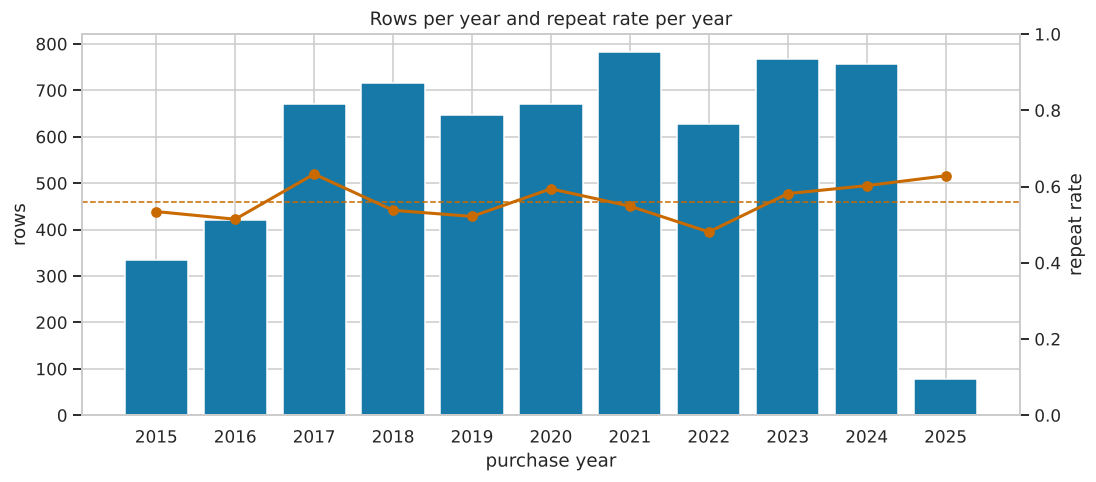

In [11]:
print(f"purchases run from {filled['purchase_date'].min():%Y-%m-%d}"
      f" to {filled['purchase_date'].max():%Y-%m-%d}")

by_year = filled.groupby(filled["purchase_date"].dt.year)[TARGET].agg(["size", "mean"])
by_year.index = by_year.index.astype(int)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(by_year.index, by_year["size"], color=PLOT_BLUE)
ax.set(xlabel="purchase year", ylabel="rows", title="Rows per year and repeat rate per year")
ax.set_xticks(by_year.index)
rate = ax.twinx()
rate.plot(by_year.index, by_year["mean"], color=PLOT_ORANGE, marker="o", lw=2)
rate.axhline(filled[TARGET].mean(), color=PLOT_ORANGE, ls="--", lw=1)
rate.set(ylabel="repeat rate", ylim=(0, 1))
rate.grid(False)
plt.show()

print(by_year.rename(columns={"size": "rows", "mean": "repeat rate"}).round(3).T.to_string())

**The purchases cover almost ten years, from July 2015 to February 2025, and the
repeat rate has no trend**: it moves between 0.48 (2022) and 0.63 (2017 and
2025) around the overall 0.56. 2025 has only 78 rows because the data ends on
15 February. The year is therefore not expected to be a strong feature by
itself, but the date is what every history column was computed from.

## <font color='#E8800A'>1.6 · Missing values</font> <a class="anchor" id="missing"></a>
[Back to TOC](#toc)

__Step 7:__ Ask where the missing values are, and along which axis.

In [12]:
rows_with_null = train.isna().any(axis=1)
per_column = train.isna().sum()

pd.Series({
    "rows with a null": f"{rows_with_null.sum():,} of {len(train):,}"
                        f" ({100 * rows_with_null.mean():.2f}%)",
    "columns with a null": f"{(per_column > 0).sum()} of {train.shape[1]}",
    "null cells": f"{train.isna().sum().sum():,}",
    "worst column": f"{per_column.idxmax()} ({per_column.max():,} nulls)",
}).to_frame("missing values as the file arrives")

,missing values as the file arrives
rows with a null,"2,605 of 6,534 (39.87%)"
columns with a null,36 of 38
null cells,"9,818"
worst column,"prior_std_gap_days (1,478 nulls)"


**2,605 of the 6,534 rows (39.87%) carry at least one null, spread over 36 of
the 38 columns: 9,818 cells in all.** Dropping incomplete rows would cost 40%
of the data and dropping incomplete columns would leave the target and the
customer id. Neither is an option, so the question becomes *why* the cells are
missing.

__Step 8:__ The history columns are the worst affected. Are they missing because
the customer has no history?

In [13]:
# Do the history columns go missing because there IS no history? Share of
# missing cells by how many purchases the customer had made before this one.
history_stats = ["days_since_previous_purchase", "prior_mean_purchase_value",
                 "prior_min_purchase_value", "prior_max_purchase_value",
                 "prior_std_purchase_value", "prior_mean_gap_days", "prior_std_gap_days"]
prior_band = pd.cut(filled["prior_purchase_count"], [-1, 0, 1, 2, np.inf],
                    labels=["0 (first purchase)", "1", "2", "3 or more"])

by_history = (100 * filled[history_stats].isna().groupby(prior_band, observed=True).mean()).round(1)
by_history.insert(0, "rows", prior_band.value_counts().sort_index())
by_history.T

prior_purchase_count,0 (first purchase),1,2,3 or more
rows,603.0,445.0,365.0,5056.0
days_since_previous_purchase,100.0,4.3,5.5,3.0
prior_mean_purchase_value,100.0,4.5,3.0,3.2
prior_min_purchase_value,100.0,0.0,0.0,0.0
prior_max_purchase_value,100.0,0.0,0.0,0.0
prior_std_purchase_value,100.0,100.0,0.0,0.0
prior_mean_gap_days,100.0,100.0,5.8,3.4
prior_std_gap_days,100.0,100.0,100.0,0.0


**Most of these blanks are not lost data. The value does not exist.** On a
first purchase all seven statistics are missing in 100% of rows. With one
earlier purchase the standard deviation and the gap statistics are still
undefined, and the spread of the gaps needs three purchases. From the point
where a statistic can be computed, its missing share drops to 0%, or to a
residual 3 to 6% in three of the columns.

__Step 9:__ Split every missing cell by its source: an empty row, a statistic
with no history to compute from, or neither.

In [14]:
# The smallest number of earlier purchases each statistic needs to exist:
# a mean or a last gap needs one, a spread or a mean gap needs two, and the
# spread of the gaps needs three purchases (two gaps).
needs_prior = {"days_since_previous_purchase": 1, "prior_mean_purchase_value": 1,
               "prior_min_purchase_value": 1, "prior_max_purchase_value": 1,
               "prior_std_purchase_value": 2, "prior_mean_gap_days": 2,
               "prior_std_gap_days": 3}

is_null = train.isna()
no_history = pd.DataFrame(False, index=train.index, columns=train.columns)
for column, minimum in needs_prior.items():
    no_history[column] = is_null[column] & (train["prior_purchase_count"] < minimum)
in_empty_row = is_null.mul(empty_row, axis=0)
scattered = is_null & ~no_history & ~in_empty_row

sources = pd.DataFrame({
    "missing": is_null.sum(),
    "in an empty row": in_empty_row.sum(),
    "no history to compute from": no_history.sum(),
    "scattered": scattered.sum(),
})
sources["scattered % of filled rows"] = (100 * sources["scattered"] / len(filled)).round(2)
sources = sources[sources["missing"] > 0].sort_values("missing", ascending=False)
print(sources.to_string())
print("\ntotals:", sources[["missing", "in an empty row", "no history to compute from",
                            "scattered"]].sum().to_dict())

                                missing  in an empty row  no history to compute from  scattered  scattered % of filled rows
prior_std_gap_days                 1478               65                        1413          0                        0.00
prior_mean_gap_days                1308               65                        1048        195                        3.01
prior_std_purchase_value           1113               65                        1048          0                        0.00
prior_mean_purchase_value           862               65                         603        194                        3.00
days_since_previous_purchase        861               65                         603        193                        2.98
prior_max_purchase_value            668               65                         603          0                        0.00
prior_min_purchase_value            668               65                         603          0                        0.00
transpor

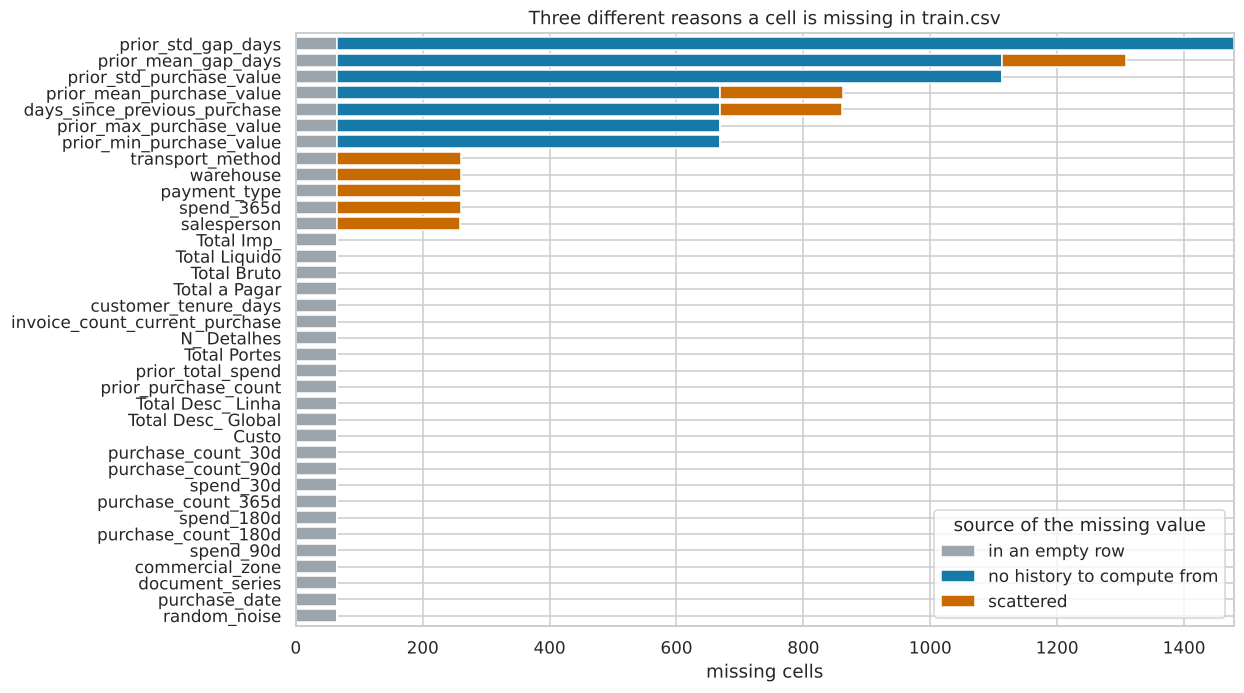

In [15]:
stacked = sources[["in an empty row", "no history to compute from", "scattered"]]

fig, ax = plt.subplots(figsize=(11, 7))
stacked.iloc[::-1].plot.barh(stacked=True, ax=ax, width=0.8,
                             color=["#9AA5AD", PLOT_BLUE, PLOT_ORANGE])
ax.set(xlabel="missing cells", ylabel="",
       title="Three different reasons a cell is missing in train.csv")
ax.legend(title="source of the missing value", loc="lower right")
plt.show()

**The 9,818 missing cells have three different sources.**

1. **2,340 cells** are the 65 empty rows (65 × 36 columns).
2. **5,921 cells** are history statistics that cannot exist yet. This kind of
   missing value is information: it says "new or nearly new customer".
3. **1,557 cells** are scattered, and they follow a pattern too regular to be
   natural: **eight columns each lose almost exactly 3% of their rows**
   (193 to 196 cells), three history columns, `spend_365d`, and four of the six
   categorical columns.

The three sources call for different treatments, so they should not be filled
by one rule. That decision belongs to Section 2.

__Step 10:__ Is the scattered 3% related to anything? Cross a per-row flag with
the label, the purchase year and each categorical feature.

In [16]:
# Is the scattered missingness related to anything? One flag per row, crossed
# with the label and with the categorical features.
scattered_row = scattered.loc[filled.index].any(axis=1)
print(f"rows carrying at least one scattered blank: {scattered_row.sum():,}"
      f" ({100 * scattered_row.mean():.2f}% of the filled rows)")
print("scattered blanks per row:",
      scattered.loc[filled.index].sum(axis=1).value_counts().sort_index().to_dict())

crossed = {TARGET: filled[TARGET],
           "purchase year": filled["purchase_date"].dt.year,
           **{column: filled[column] for column in categorical}}
rows = []
for name, values in crossed.items():
    table = pd.crosstab(scattered_row, values)
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"crossed with": name, "levels": table.shape[1], "chi2": chi2,
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
pd.DataFrame(rows).set_index("crossed with").round(4)

rows carrying at least one scattered blank: 1,431 (22.12% of the filled rows)
scattered blanks per row: {0: 5038, 1: 1311, 2: 114, 3: 6}


,levels,chi2,Cramer's V,p,min expected count
crossed with,,,,,
repeat_purchase_90d,2,5.3980,0.0289,0.0202,630.0028
purchase year,11,23.5205,0.0603,0.0090,17.2543
payment_type,9,7.7145,0.0351,0.4618,0.7880
salesperson,9,8.4621,0.0367,0.3897,0.5914
commercial_zone,5,4.1029,0.0252,0.3923,0.2212
transport_method,80,77.8786,0.1114,0.5146,0.1969
warehouse,2,0.8094,0.0114,0.3683,4.1371
document_series,3,6.3522,0.0313,0.0417,404.3698


**The scattered blanks look close to random.** 1,431 rows carry at least one,
almost always exactly one, so the eight columns are hit independently. No
association is stronger than a Cramér's V of 0.11, and that one
(`transport_method`) has 80 levels and expected counts below 1, so its
chi-square is not reliable. With eight tests the conservative threshold is
0.05 / 8 = 0.006, and none passes it. The purchase year is nearest
(p = 0.009, V = 0.06) and the label has p = 0.020 with V = 0.029; both
associations are too weak to act on.

Rows are therefore not missing these values *because of* their outcome, and a
simple fill fitted on the training rows is defensible for this third source.

## <font color='#E8800A'>1.7 · Descriptive statistics and distributions</font> <a class="anchor" id="distributions"></a>
[Back to TOC](#toc)

__Step 11:__ Describe the 28 numeric columns.

In [17]:
summary = filled[numeric].describe().T
summary.round(2)

,count,mean,std,min,25%,50%,75%,max
Total a Pagar,6469.0,925.56,1335.00,0.93,188.92,476.74,1087.67,2.229721e+04
Total Bruto,6469.0,886.15,1327.64,0.83,175.74,445.74,1036.70,2.157828e+04
Total Liquido,6469.0,773.34,1136.36,0.76,154.38,389.91,903.37,1.812781e+04
Total Imp_,6469.0,152.22,225.26,0.00,29.93,79.74,184.84,4.169400e+03
Total Portes,6469.0,1.15,5.84,0.00,0.00,0.00,0.00,1.810600e+02
Total Desc_ Global,6469.0,0.35,5.12,0.00,0.00,0.00,0.00,2.184900e+02
Total Desc_ Linha,6469.0,112.47,289.99,0.00,0.00,13.13,92.28,4.103440e+03
Custo,6469.0,328.17,519.51,0.00,49.05,152.54,396.06,7.427400e+03
N_ Detalhes,6469.0,21.52,27.71,1.00,4.00,11.00,29.00,4.230000e+02
invoice_count_current_purchase,6469.0,1.07,0.31,1.00,1.00,1.00,1.00,5.000000e+00


Read row by row, three things stand out.

- **The typical purchase is small and the range is wide.** The median
  `Total a Pagar` is 476.74 and the largest is 22,297.21.
- **Two means cannot be right.** `prior_mean_purchase_value` averages
  2.8 million and `spend_365d` 2.4 million, with a maximum of exactly
  1,000,000,000 in both, while their medians are 724.90 and 2,426.60.
- **Four minimums are negative**: `days_since_previous_purchase` and
  `prior_mean_gap_days` at −4, and two amounts. A number of days or an amount
  spent cannot be below zero.

The second and third points are taken up in Section 1.8.

__Step 12:__ Add what `.describe()` leaves out: skew, the share of zeros, and
the ratio of mean to median.

In [18]:
shape = summary.copy()
# The 50% column IS the median, so the ratio comes from the frame itself.
# A median of zero leaves it undefined rather than infinite.
shape["mean/median"] = shape["mean"] / shape["50%"].replace(0, np.nan)
shape["skew"] = filled[numeric].skew()
shape["% zeros"] = 100 * (filled[numeric] == 0).mean()
shape["% negative"] = 100 * (filled[numeric] < 0).mean()
shape = shape.sort_values("skew", ascending=False)

shape[["mean", "50%", "mean/median", "skew", "% zeros", "% negative"]].round(2)

,mean,50%,mean/median,skew,% zeros,% negative
Total Desc_ Global,0.35,0.00,NaN,27.46,98.30,0.00
prior_max_purchase_value,2946.38,1783.24,1.65,21.34,0.00,0.00
spend_365d,2396534.88,2426.60,987.61,20.38,12.52,0.23
Total Portes,1.15,0.00,NaN,19.55,83.72,0.00
prior_mean_purchase_value,2821825.32,724.90,3892.73,18.75,0.00,0.25
prior_mean_gap_days,95.88,68.44,1.40,9.30,0.00,0.25
prior_std_gap_days,74.14,50.64,1.46,7.77,0.02,0.00
days_since_previous_purchase,101.53,57.00,1.78,6.53,0.00,0.25
invoice_count_current_purchase,1.07,1.00,1.07,6.44,0.00,0.00
Total Desc_ Linha,112.47,13.13,8.57,5.92,37.73,0.00


**Every numeric column except `customer_tenure_days` is strongly right-skewed.**
Leaving aside the two columns distorted by the 1,000,000,000 entries, the mean
is typically about twice the median (1.94 for `Total a Pagar`, 2.80 for
`prior_total_spend`) and skew runs from 2 to 27.

**Several columns are mostly zero**: `Total Desc_ Global` in 98% of rows,
`Total Portes` in 84%, and the 30-day window in 67%. For these the median is 0
and the mean/median ratio is undefined, so the share of non-zero rows describes
them better than any average.

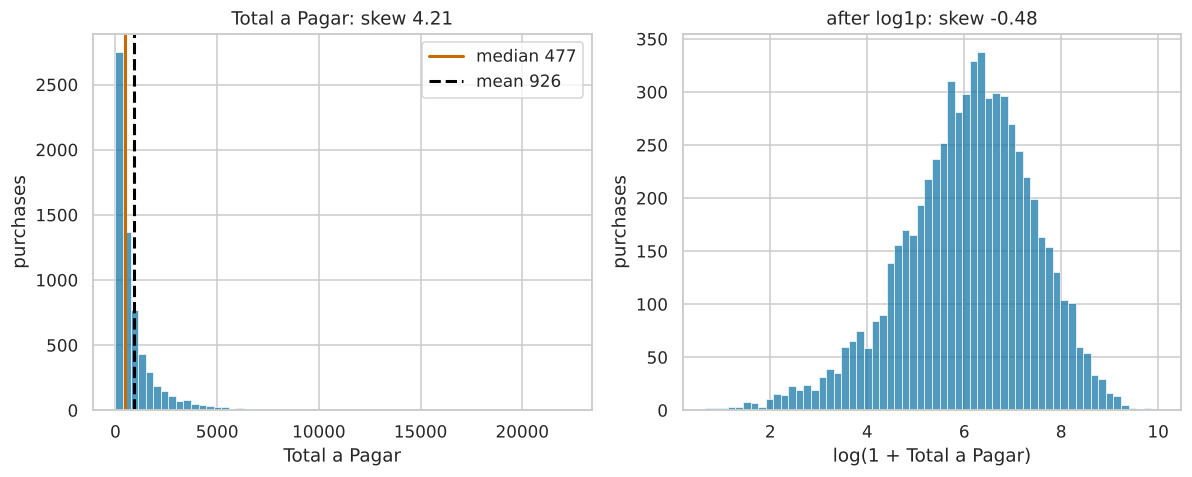

In [19]:
fig, (left, right) = plt.subplots(1, 2, figsize=FIGSIZE)
column = "Total a Pagar"
sns.histplot(filled[column], bins=60, color=PLOT_BLUE, ax=left)
left.axvline(filled[column].median(), color=PLOT_ORANGE, lw=2,
             label=f"median {filled[column].median():,.0f}")
left.axvline(filled[column].mean(), color="black", lw=2, ls="--",
             label=f"mean {filled[column].mean():,.0f}")
left.set(xlabel=column, ylabel="purchases", title=f"{column}: skew {filled[column].skew():.2f}")
left.legend()

sns.histplot(np.log1p(filled[column]), bins=60, color=PLOT_BLUE, ax=right)
right.set(xlabel=f"log(1 + {column})", ylabel="purchases",
          title=f"after log1p: skew {np.log1p(filled[column]).skew():.2f}")
plt.tight_layout()
plt.show()

**Median 477, mean 926.** On the raw scale almost all purchases are squeezed
into the first bars and the mean sits to the right of where most rows are. After
`log1p` the same column is close to symmetric (skew −0.48), which is why the
plots below and the correlations in Section 1.11 use the log scale.

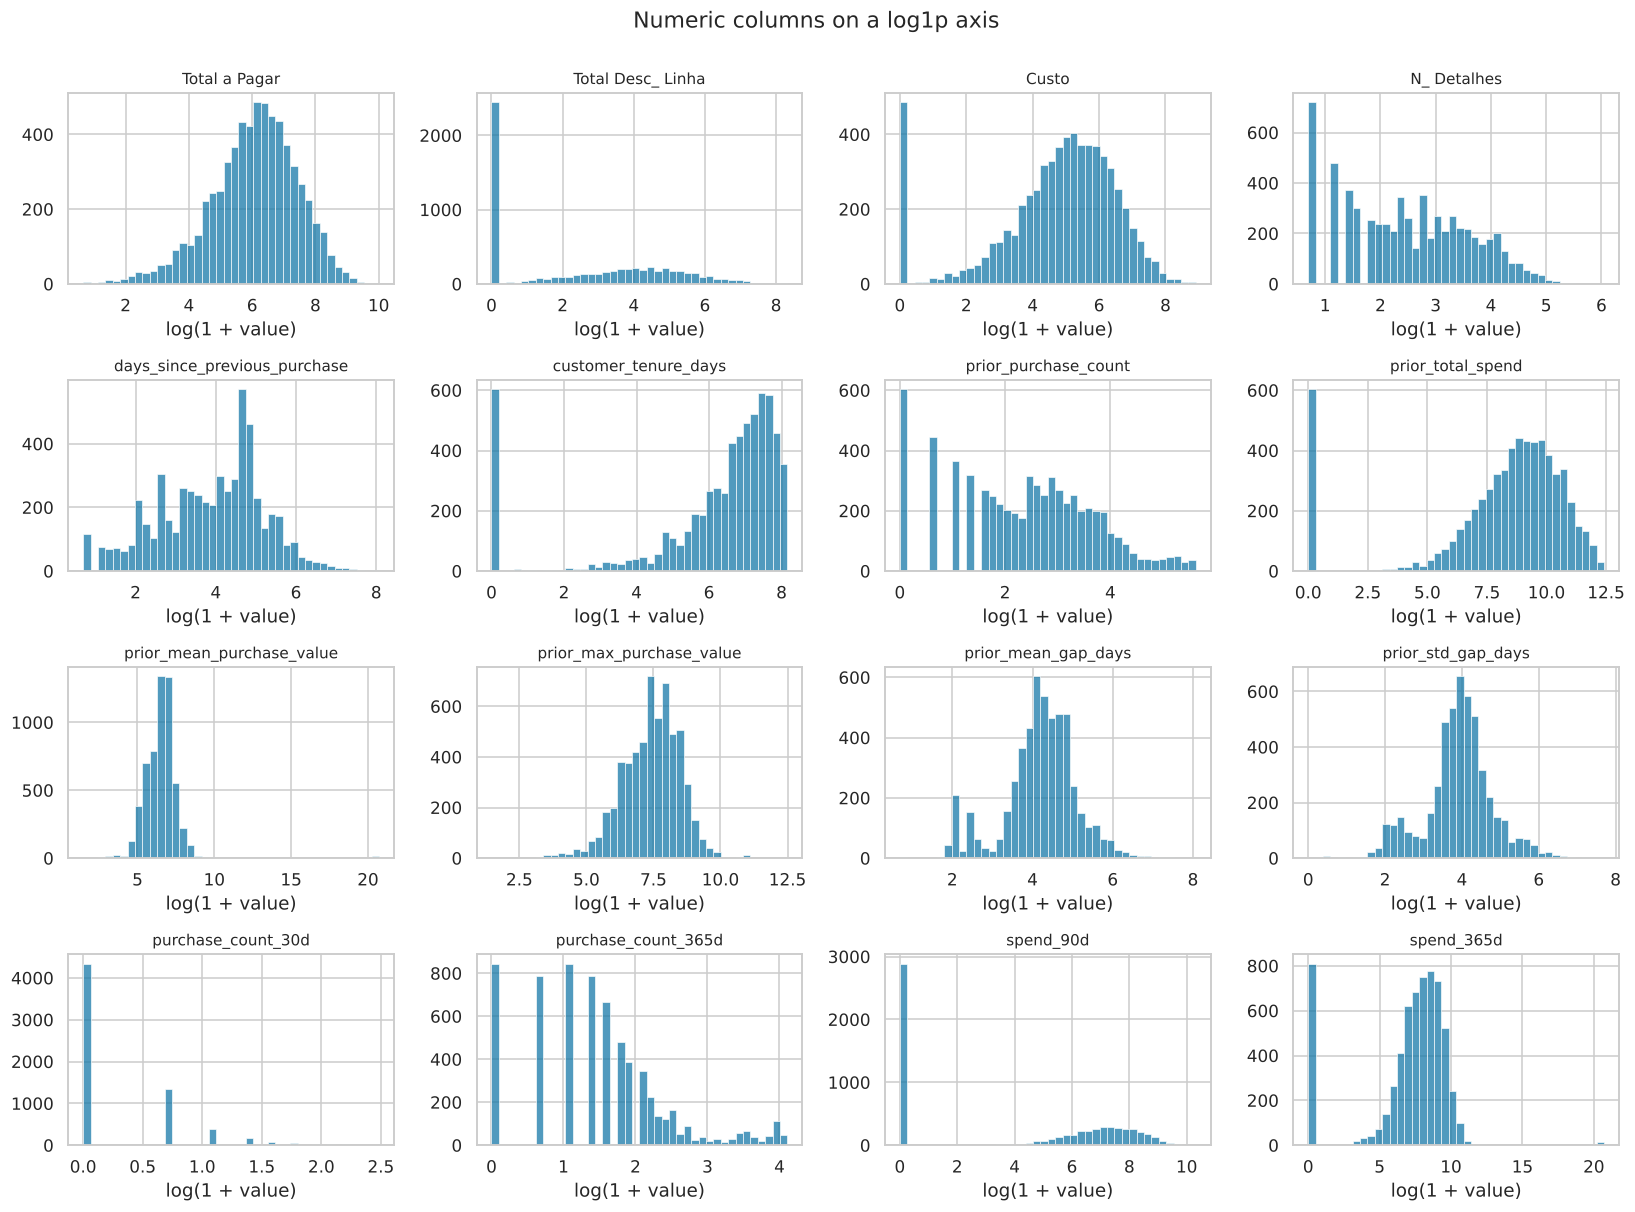

In [20]:
# Sixteen of the numeric columns on a log1p axis. Values that cannot be logged
# (negatives) are left out of the picture and counted in the next section.
grid_columns = ["Total a Pagar", "Total Desc_ Linha", "Custo", "N_ Detalhes",
                "days_since_previous_purchase", "customer_tenure_days",
                "prior_purchase_count", "prior_total_spend",
                "prior_mean_purchase_value", "prior_max_purchase_value",
                "prior_mean_gap_days", "prior_std_gap_days",
                "purchase_count_30d", "purchase_count_365d", "spend_90d", "spend_365d"]

fig, axes = plt.subplots(4, 4, figsize=(15, 11))
for ax, column in zip(axes.ravel(), grid_columns):
    values = filled[column].dropna()
    sns.histplot(np.log1p(values[values >= 0]), bins=40, color=PLOT_BLUE, ax=ax)
    ax.set(title=column, xlabel="log(1 + value)", ylabel="")
    ax.title.set_fontsize(10)
plt.suptitle("Numeric columns on a log1p axis", y=1.0)
plt.tight_layout()
plt.show()

On the log scale the amount columns are roughly bell-shaped, while the count
and window columns keep a spike at zero: customers with no recent activity.
That spike is a real group, not a tail to be trimmed. The x-axis of
`prior_mean_purchase_value` and `spend_365d` stretches to 20 because of a few
entries of 1,000,000,000, which Section 1.8 examines.

__Step 13:__ Apply the 1.5 × IQR rule as a screen, and see what it would call
an outlier.

                               Q1        Q3  % of rows outside the fences
spend_30d                    0.00    338.24                         16.39
Total Portes                 0.00      0.00                         16.28
Total Desc_ Linha            0.00     92.28                         12.71
purchase_count_180d          1.00      3.00                         11.39
prior_min_purchase_value    15.45    162.61                         10.37
spend_90d                    0.00   1514.56                         10.22
prior_total_spend         1505.55  21642.32                          9.92
Total a Pagar              188.92   1087.67                          9.15
Total Liquido              154.38    903.37                          9.07
Total Bruto                175.74   1036.70                          9.03

rows outside the fences on at least one column: 4,300 of 6,469 (66.5%)
repeat rate among those rows: 0.603   among the rest: 0.473


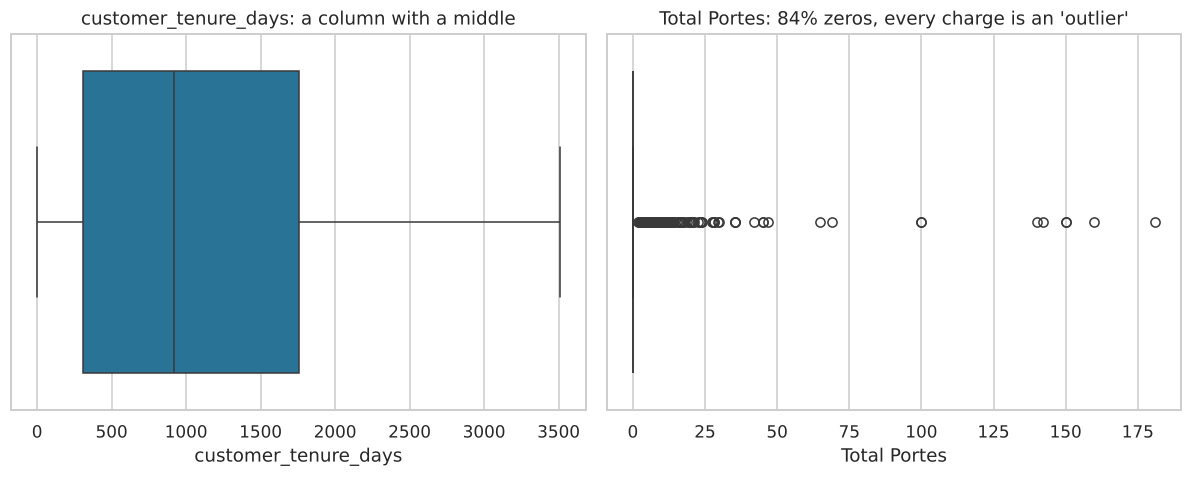

In [21]:
# The 1.5 x IQR rule on every numeric column: how many rows would it call outliers?
q1, q3 = filled[numeric].quantile(0.25), filled[numeric].quantile(0.75)
iqr = q3 - q1
outside = (filled[numeric] < q1 - 1.5 * iqr) | (filled[numeric] > q3 + 1.5 * iqr)

flagged = pd.DataFrame({"Q1": q1, "Q3": q3,
                        "% of rows outside the fences": 100 * outside.mean()})
print(flagged.sort_values("% of rows outside the fences", ascending=False)
      .head(10).round(2).to_string())
print(f"\nrows outside the fences on at least one column: {outside.any(axis=1).sum():,}"
      f" of {len(filled):,} ({100 * outside.any(axis=1).mean():.1f}%)")
print(f"repeat rate among those rows: {filled.loc[outside.any(axis=1), TARGET].mean():.3f}"
      f"   among the rest: {filled.loc[~outside.any(axis=1), TARGET].mean():.3f}")

fig, (left, right) = plt.subplots(1, 2, figsize=FIGSIZE)
sns.boxplot(x=filled["customer_tenure_days"], color=PLOT_BLUE, ax=left)
left.set(title="customer_tenure_days: a column with a middle")
sns.boxplot(x=filled["Total Portes"], color=PLOT_BLUE, ax=right)
right.set(title="Total Portes: 84% zeros, every charge is an 'outlier'")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

**The IQR rule flags 66.5% of the rows on at least one column**, and those rows
repeat more often (0.603) than the rest (0.473). The rule is not finding
errors here. It is finding active customers and, on columns like
`Total Portes` where Q1 = Q3 = 0, every row that is not zero.

Removing rows by this rule would delete two thirds of the data and change the
class balance. The long tails are a matter for a transformation, and the
genuinely wrong values are found by the domain rules in the next section.

</div>

## <font color='#E8800A'>1.8 · Impossible values and inconsistencies</font> <a class="anchor" id="invalid"></a>
[Back to TOC](#toc)

Some cells are not extreme. They are impossible, and that is decided by what
the column measures before any result is looked at: a duration in days and an
amount spent are never negative, and a mean cannot exceed what was spent in
total.

__Step 14:__ Look at the suspicious values by value.

In [22]:
# Values no amount or duration can take. Random damage scatters across many
# values; a placeholder piles up on one.
print("largest values of the two columns whose mean is in the millions:")
for column in ["prior_mean_purchase_value", "spend_365d"]:
    top = filled[column].value_counts().sort_index(ascending=False).head(3)
    print(f"  {column:28s}", {f"{value:,.2f}": count for value, count in top.items()})

print("\nnegative values, by column:")
for column in numeric:
    negative = filled.loc[filled[column] < 0, column]
    if len(negative):
        print(f"  {column:30s} {len(negative):3d} rows,"
              f" {negative.nunique():2d} distinct value(s), min {negative.min():,.2f}")

largest values of the two columns whose mean is in the millions:
  prior_mean_purchase_value    {'1,000,000,000.00': 16, '72,937.16': 1, '30,448.60': 1}
  spend_365d                   {'1,000,000,000.00': 15, '522,933.21': 1, '444,752.99': 1}

negative values, by column:
  days_since_previous_purchase    16 rows,  1 distinct value(s), min -4.00
  prior_mean_purchase_value       16 rows, 16 distinct value(s), min -2,478.66
  prior_mean_gap_days             16 rows,  1 distinct value(s), min -4.00
  spend_365d                      15 rows, 15 distinct value(s), min -159,115.18


<div class="alert alert-block alert-warning">

**Two kinds of placeholder, and one kind of damage.**

- **1,000,000,000 appears 16 times in `prior_mean_purchase_value` and 15 times
  in `spend_365d`.** One round number repeated is a code, not a measurement.
  The next largest values are 72,937 and 522,933.
- **−4 appears 16 times in `days_since_previous_purchase` and 16 times in
  `prior_mean_gap_days`**, always the same value. Again a code.
- **The negative amounts are all different** (16 and 15 distinct values), so
  they are not a code.

</div>

In [23]:
# Are the negative amounts noise, or real values with the wrong sign? Two
# columns can be recomputed from other columns of the same row.
negative_mean = filled["prior_mean_purchase_value"] < 0
recomputed = filled["prior_total_spend"] / filled["prior_purchase_count"]
print("negative prior_mean_purchase_value equal to -(prior_total_spend / prior_purchase_count):",
      f"{np.isclose(-filled.loc[negative_mean, 'prior_mean_purchase_value'], recomputed[negative_mean]).sum()}"
      f" of {negative_mean.sum()}")

filled.loc[filled["spend_365d"] < 0,
           ["spend_180d", "spend_365d", "prior_total_spend", "prior_purchase_count"]].head(6).round(2)

negative prior_mean_purchase_value equal to -(prior_total_spend / prior_purchase_count): 16 of 16


,spend_180d,spend_365d,prior_total_spend,prior_purchase_count
ID,,,,
10000300,577.67,-3456.32,3456.32,5.0
10002022,264.00,-1230.72,5129.20,7.0
10002033,0.00,-167.18,2586.88,15.0
10002134,0.00,-753.51,753.51,2.0
10002452,2234.61,-2648.44,28625.97,33.0
10003340,0.00,-2169.91,31123.69,36.0


**The negative amounts are real values with the sign flipped.** All 16 negative
`prior_mean_purchase_value` cells equal minus the mean recomputed from
`prior_total_spend / prior_purchase_count`. The negative `spend_365d` cells
have plausible magnitudes too (the first one equals the customer's total
earlier spend). The sign is wrong and the size is informative, which matters
for how they are repaired.

__Step 15:__ Check the relations that must hold between columns by their own
definitions.

In [24]:
# Cross-column rules: relations that must hold by the definition of the
# columns. Each rule is True where a row BREAKS it. Rows where a needed value
# is missing, or is one of the placeholders above, are not counted against it.
f = filled
plausible_mean = f["prior_mean_purchase_value"].between(0, 1e8)
plausible_365 = f["spend_365d"].between(0, 1e8)
cent = 0.011  # amounts are stored to the cent

rules = {
    "gross - line discount - global discount != net":
        (f["Total Bruto"] - f["Total Desc_ Linha"] - f["Total Desc_ Global"] - f["Total Liquido"]).abs() > cent,
    "net + tax != amount payable":
        (f["Total Liquido"] + f["Total Imp_"] - f["Total a Pagar"]).abs() > cent,
    "cost is zero on a sale with a positive net amount":
        (f["Custo"] == 0) & (f["Total Liquido"] > 0),
    "cost above the net amount (sold at a loss)":
        f["Custo"] > f["Total Liquido"],
    "tenure is zero but there are earlier purchases (or the reverse)":
        (f["customer_tenure_days"] == 0) != (f["prior_purchase_count"] == 0),
    "window counts not nested (30d <= 90d <= 180d <= 365d <= all earlier)":
        (f["purchase_count_30d"] > f["purchase_count_90d"])
        | (f["purchase_count_90d"] > f["purchase_count_180d"])
        | (f["purchase_count_180d"] > f["purchase_count_365d"])
        | (f["purchase_count_365d"] > f["prior_purchase_count"]),
    "window spend not nested (30d <= 90d <= 180d)":
        (f["spend_30d"] > f["spend_90d"] + cent) | (f["spend_90d"] > f["spend_180d"] + cent),
    "spend_365d below spend_180d":
        plausible_365 & (f["spend_365d"] < f["spend_180d"] - cent),
    "spend_365d above prior_total_spend":
        plausible_365 & (f["spend_365d"] > f["prior_total_spend"] + cent),
    "days since previous purchase above customer tenure":
        f["days_since_previous_purchase"] > f["customer_tenure_days"],
    "prior_mean_gap_days above customer tenure":
        f["prior_mean_gap_days"] > f["customer_tenure_days"],
    "prior_mean_purchase_value != prior_total_spend / prior_purchase_count":
        plausible_mean & ((f["prior_mean_purchase_value"] - recomputed).abs() > cent),
    "prior_max_purchase_value above prior_total_spend":
        f["prior_max_purchase_value"] > f["prior_total_spend"] + cent,
    "prior_min_purchase_value above prior_max_purchase_value":
        f["prior_min_purchase_value"] > f["prior_max_purchase_value"] + cent,
}
violations = pd.DataFrame({
    "rows breaking the rule": {name: int(broken.sum()) for name, broken in rules.items()},
    "% of filled rows": {name: round(100 * broken.mean(), 2) for name, broken in rules.items()},
})
violations

,rows breaking the rule,% of filled rows
gross - line discount - global discount != net,0,0.00
net + tax != amount payable,0,0.00
cost is zero on a sale with a positive net amount,486,7.51
cost above the net amount (sold at a loss),39,0.60
tenure is zero but there are earlier purchases (or the reverse),0,0.00
window counts not nested (30d <= 90d <= 180d <= 365d <= all earlier),0,0.00
window spend not nested (30d <= 90d <= 180d),0,0.00
spend_365d below spend_180d,0,0.00
spend_365d above prior_total_spend,39,0.60
days since previous purchase above customer tenure,0,0.00


**The invoice columns are internally consistent.** Gross minus the two discounts
equals net, and net plus tax equals the amount payable, on every row. That
confirms the reading of the column names in Section 1.3, and it means these
columns are exact functions of each other. The history is consistent too:
window counts and window spends are nested, and tenure is zero exactly when
there is no earlier purchase.

**Four rules fail, and three of them point at corrupted cells.**

- `prior_mean_purchase_value` disagrees with total / count on **46 rows**.
- `prior_max_purchase_value` exceeds the customer's total earlier spend on
  **45 rows**.
- `spend_365d` exceeds the customer's total earlier spend on **39 rows**.
- `Custo` is zero on **486 sales (7.51%)** with a positive net amount, and
  exceeds the net amount on 39. These are possible in a business, so they are
  looked at separately.

In [25]:
# The two rules that fail on a few dozen rows: by how much?
too_big_max = rules["prior_max_purchase_value above prior_total_spend"]
wrong_mean = rules["prior_mean_purchase_value != prior_total_spend / prior_purchase_count"]

ratio_max = (f["prior_max_purchase_value"] / f["prior_total_spend"])[too_big_max]
ratio_mean = (f["prior_mean_purchase_value"] / recomputed)[wrong_mean]
print("prior_max_purchase_value / prior_total_spend on the rows that break the rule:")
print(ratio_max.describe()[["count", "min", "50%", "max"]].round(2).to_string())
print("\nprior_mean_purchase_value / recomputed mean on the rows that break the rule:")
print(ratio_mean.describe()[["count", "min", "50%", "max"]].round(2).to_string())

print("\nlargest single earlier purchase reported, against the largest purchase in the file:")
print(f"  prior_max_purchase_value max {f['prior_max_purchase_value'].max():>12,.2f}")
print(f"  Total a Pagar max            {f['Total a Pagar'].max():>12,.2f}")
print(f"  rows whose prior max exceeds every purchase in the file:"
      f" {(f['prior_max_purchase_value'] > f['Total a Pagar'].max()).sum()}")

prior_max_purchase_value / prior_total_spend on the rows that break the rule:
count    45.00
min       1.08
50%       4.26
max      22.31

prior_mean_purchase_value / recomputed mean on the rows that break the rule:
count    46.00
min       8.48
50%      16.07
max      24.81

largest single earlier purchase reported, against the largest purchase in the file:
  prior_max_purchase_value max   267,526.19
  Total a Pagar max               22,297.21
  rows whose prior max exceeds every purchase in the file: 27


**The failing cells are inflated, not slightly off.** The wrong means are 8 to 25
times the recomputed mean (median 16 times), and the wrong maxima are up to 22
times the customer's entire earlier spend. 27 rows report an earlier purchase
larger than the largest purchase in the whole file (267,526 against 22,297).
A boxplot would not single these out from the genuine tail; the cross-column
rules do.

In [26]:
zero_cost = rules["cost is zero on a sale with a positive net amount"]
pd.DataFrame({
    "rows": zero_cost.value_counts(),
    "median Total a Pagar": filled.groupby(zero_cost)["Total a Pagar"].median(),
    "median N_ Detalhes": filled.groupby(zero_cost)["N_ Detalhes"].median(),
    "repeat rate": filled.groupby(zero_cost)[TARGET].mean(),
}).rename(index={False: "cost recorded", True: "cost = 0"}).round(3)

,rows,median Total a Pagar,median N_ Detalhes,repeat rate
cost recorded,5983,490.130,13.0,0.550
cost = 0,486,229.755,2.0,0.677


**Zero cost is a pattern, not an obvious error.** The 486 zero-cost sales are
small (median 230 against 490, 2 invoice lines against 12) and are followed by
a repeat purchase more often (0.677 against 0.550). The value may be an
unrecorded cost or a real type of sale; we cannot tell from the file. It is
kept as it is and noted as a candidate indicator feature.

__Step 16:__ Count every impossible cell once.

In [27]:
# Every cell the checks above call impossible, as one mask over the frame.
impossible = pd.DataFrame(False, index=filled.index, columns=filled.columns)
for column in ["days_since_previous_purchase", "prior_mean_gap_days",
               "prior_mean_purchase_value", "spend_365d"]:
    impossible[column] |= filled[column] < 0
for column in ["prior_mean_purchase_value", "spend_365d"]:
    impossible[column] |= filled[column] >= 1e8
impossible["prior_mean_purchase_value"] |= wrong_mean
impossible["prior_max_purchase_value"] |= too_big_max
impossible["spend_365d"] |= rules["spend_365d below spend_180d"] | rules["spend_365d above prior_total_spend"]

per_invalid = impossible.sum()
print(per_invalid[per_invalid > 0].to_frame("impossible cells").to_string())
print(f"\n{impossible.sum().sum()} impossible cells on {impossible.any(axis=1).sum()} rows"
      f" ({100 * impossible.any(axis=1).mean():.2f}% of the filled rows)")
print(f"repeat rate on those rows: {filled.loc[impossible.any(axis=1), TARGET].mean():.3f}"
      f"   on the rest: {filled.loc[~impossible.any(axis=1), TARGET].mean():.3f}")

                              impossible cells
days_since_previous_purchase                16
prior_mean_purchase_value                   78
prior_max_purchase_value                    45
prior_mean_gap_days                         16
spend_365d                                  69

224 impossible cells on 223 rows (3.45% of the filled rows)
repeat rate on those rows: 0.538   on the rest: 0.561


**224 cells on 223 rows (3.45%) hold a value that cannot be true**, in five
columns. Their repeat rate (0.538) is close to that of the other rows (0.561),
so the damage is not tied to the outcome.

Two of the five columns can be rebuilt exactly from columns that are intact
(`prior_mean_purchase_value` from total / count; a flipped sign by taking the
absolute value). The others can only be blanked and treated as missing.
The `impossible` mask is reused in Section 1.11 so that these cells do not
distort the correlations.

## <font color='#E8800A'>1.9 · Categorical variables</font> <a class="anchor" id="categorical"></a>
[Back to TOC](#toc)

__Step 17:__ Count the levels, and how the rows are spread over them.

In [28]:
levels = pd.DataFrame({
    "levels": filled[categorical].nunique(),
    "largest level %": [100 * filled[c].value_counts(normalize=True).iloc[0] for c in categorical],
    "levels under 10 rows": [(filled[c].value_counts() < 10).sum() for c in categorical],
    "missing %": 100 * filled[categorical].isna().mean(),
})
print(levels.round(2).to_string())

# Spelling check: would trimming spaces or lower-casing merge any two levels?
for column in categorical:
    cleaned = filled[column].dropna().str.strip().str.lower()
    assert cleaned.nunique() == filled[column].nunique(), column
print("\nno level differs from another only by case or surrounding spaces")

                  levels  largest level %  levels under 10 rows  missing %
payment_type           9            72.76                     3       3.01
salesperson            9            64.61                     2       3.00
commercial_zone        5            96.77                     2       0.00
transport_method      80            17.84                    40       3.03
warehouse              2            99.67                     0       3.01
document_series        3            42.32                     0       0.00

no level differs from another only by case or surrounding spaces


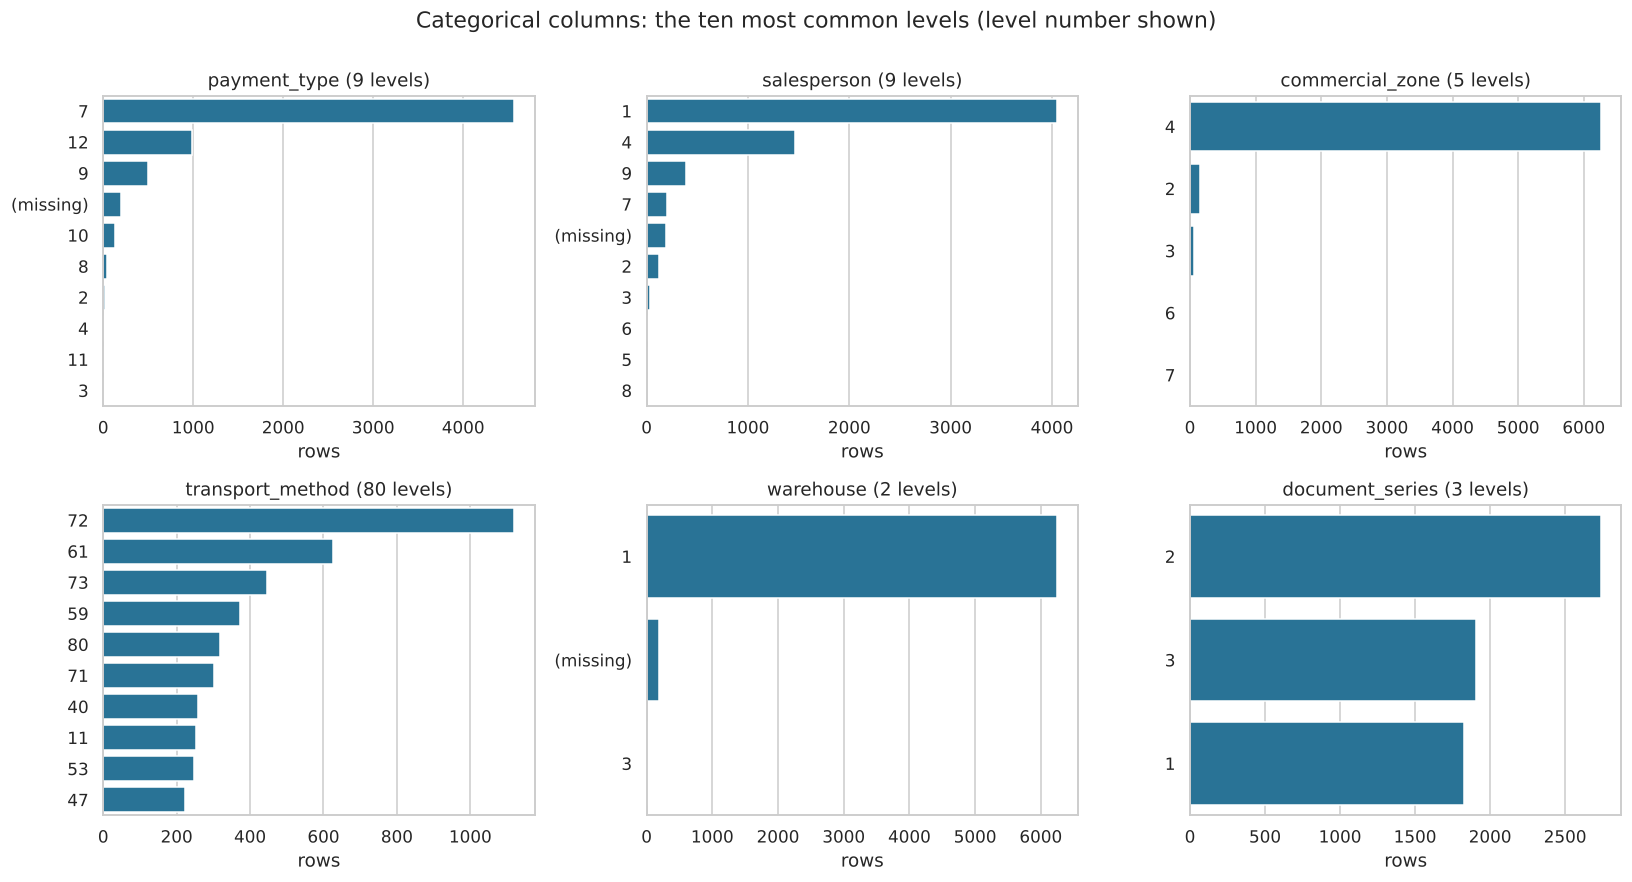

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), categorical):
    counts = filled[column].fillna("(missing)").value_counts().head(10)
    # The level names share a long prefix; the last token is what differs.
    labels = [label if label == "(missing)" else label.split()[-1] for label in counts.index]
    sns.barplot(x=counts.values, y=labels, color=PLOT_BLUE, ax=ax)
    ax.set(title=f"{column} ({filled[column].nunique()} levels)", xlabel="rows", ylabel="")
plt.suptitle("Categorical columns: the ten most common levels (level number shown)", y=1.0)
plt.tight_layout()
plt.show()

**The six categorical columns hold 108 levels between them, 80 of them in
`transport_method`**, where half the levels (40) have fewer than 10 rows.
Encoding turns levels into columns, so this is the column where rare levels
need a decision.

**Two columns are almost constant**: `warehouse` has one level on 99.67% of
rows and `commercial_zone` on 96.77%. They can carry very little information.
`payment_type` and `salesperson` are concentrated as well (73% and 65% on one
level) with a few levels under 10 rows.

The labels are clean: no two levels differ only by case or spacing, so there
is no misspelt category to merge. `document_series` is the only balanced one
(42 / 29 / 28%).

## <font color='#E8800A'>1.10 · The customer table, clientes.csv</font> <a class="anchor" id="clientes"></a>
[Back to TOC](#toc)

The second file holds one row per customer. Three questions decide whether it
is useful: can it be joined safely, what is filled in, and does it agree with
`train.csv`.

__Step 18:__ Survey the columns.

In [30]:
cli_survey = pd.DataFrame({
    "dtype": clientes.dtypes.astype(str),
    "missing": clientes.isna().sum(),
    "missing %": (100 * clientes.isna().mean()).round(1),
    "distinct": clientes.nunique(),
    "largest level %": [round(100 * clientes[c].value_counts(normalize=True).iloc[0], 1)
                        if clientes[c].notna().any() else np.nan for c in clientes.columns],
    "example": clientes.iloc[2].astype(str).str.slice(0, 40),
})
cli_survey

,dtype,missing,missing %,distinct,largest level %,example
customer_id,int64,0,0.0,1143,0.1,827053
country_or_region,str,0,0.0,11,94.4,Country CT10: Land of The Final Version
commercial_region,str,114,10.0,37,50.4,Region RG17: We Will See Later
island,str,578,50.6,10,23.5,Island IS2: The Pivot Archipelago
municipality,str,159,13.9,183,5.9,Municipality MU14: Council of Last Minut
city,str,546,47.8,417,2.3,NaN
postal_area,str,71,6.2,271,5.3,Postal area PA271: Hidden Sheet Sector
postal_code,str,170,14.9,828,0.6,Postal code PC827: #REF! Delivery Route
street,str,598,52.3,511,0.9,Street ST170: PowerPoint New Walk
address,str,6,0.5,1120,0.3,Address AD449: Cell Without a Home


**1,143 customers and 13 columns, almost all of them location.**

- **`customer_type` is empty for every customer**, so it has nothing to offer.
- The location columns form a hierarchy from coarse to fine. The coarse end is
  nearly constant (`country_or_region`: 94.4% in one country) and the fine end
  is nearly unique (`address` 1,120 levels, `postal_code` 828, `street` 511 on
  1,143 customers), which makes those identifiers of the customer. Only the
  middle levels (`commercial_region` with 37 levels, `island` with 10) are
  usable as groups.
- Missingness is heavy and uneven: `street` 52%, `island` 51%, `city` 48%,
  against 10% for `commercial_region`.
- `company_name` is distinct for 1,141 of 1,143 customers: an identifier.

__Step 19:__ Check the join key.

In [31]:
print("customer_id unique in clientes.csv:", clientes["customer_id"].is_unique)
print("exact duplicate rows:", clientes.duplicated().sum())

train_customers = set(train["customer_id"])
print(f"\ncustomers in train.csv found in clientes.csv:"
      f" {len(train_customers & set(clientes['customer_id']))} of {len(train_customers)}")
print(f"customers in clientes.csv that never appear in train.csv:"
      f" {(~clientes['customer_id'].isin(train_customers)).sum()} of {len(clientes)}")

# Two ids, one company?
same_name = clientes[clientes.duplicated("company_name", keep=False)]
print(f"\ncompany names shared by more than one customer_id: {same_name['company_name'].nunique()}")
same_name[["customer_id", "company_name", "postal_code", "address", "customer_since_year"]]

customer_id unique in clientes.csv: True
exact duplicate rows: 0

customers in train.csv found in clientes.csv: 610 of 610
customers in clientes.csv that never appear in train.csv: 533 of 1143

company names shared by more than one customer_id: 2


,customer_id,company_name,postal_code,address,customer_since_year
390,255774,Excel Is Not A Database Ltd 384,Postal code PC568: #REF! Delivery Route,Address AD414: Cell Without a Home,2021
391,714679,Excel Is Not A Database Ltd 384,Postal code PC568: #REF! Delivery Route,Address AD414: Cell Without a Home,2017
998,652673,Excel Is Not A Database Ltd 664,Postal code PC150: #REF! Delivery Route,Address AD975: Cell Without a Home,2015
999,821383,Excel Is Not A Database Ltd 664,Postal code PC150: #REF! Delivery Route,Address AD1047: Cell Without a Home,2015


**The join is safe.** `customer_id` is unique in `clientes.csv`, and all 610
customers of `train.csv` are found there, so a left join on `customer_id` adds
columns without adding, losing or duplicating any purchase.

533 customers in the table never appear in `train.csv`; they may be customers
of `test.csv` or customers with no purchase in the data.

**Two pairs of ids share a company name and a postal code**, and one pair
shares the address as well. They may be the same company registered twice.
It concerns 4 of 1,143 customers, so it is noted and not acted on.

__Step 20:__ `customer_since_year` is the only numeric column. Check it against
a second source for the same fact: the first purchase implied by `train.csv`.

In [32]:
since = clientes["customer_since_year"].value_counts().sort_index()
print(since.to_frame("customers").T.to_string())

# A second source for the same fact: the first purchase implied by train.csv.
first_purchase = (filled["purchase_date"]
                  - pd.to_timedelta(filled["customer_tenure_days"], unit="D")).dt.year
implied = first_purchase.groupby(filled["customer_id"]).agg(["min", "nunique"])
print("\ncustomers whose rows all imply the same first-purchase year:",
      f"{(implied['nunique'] == 1).sum()} of {len(implied)}")

compare = implied.join(clientes.set_index("customer_id")["customer_since_year"])
difference = compare["min"] - compare["customer_since_year"]
print("first purchase year minus customer_since_year, per customer:")
print(pd.cut(difference, [-np.inf, -1, 0, 1, 3, np.inf],
             labels=["earlier than registration", "same year", "1 year later",
                     "2-3 years later", "4+ years later"]).value_counts().sort_index().to_string())
print("customers that appear only in empty rows, so no date to compare:",
      train["customer_id"].nunique() - len(implied))
print(f"\nlatest purchase in train.csv: {filled['purchase_date'].max():%Y-%m-%d};"
      f" customers registered after that year: {(clientes['customer_since_year'] > filled['purchase_date'].dt.year.max()).sum()}")

customer_since_year  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
customers             664    53    82    61    47    50    52    43    29    31    18    13

customers whose rows all imply the same first-purchase year: 607 of 607
first purchase year minus customer_since_year, per customer:
earlier than registration      0
same year                    412
1 year later                 137
2-3 years later               32
4+ years later                26
customers that appear only in empty rows, so no date to compare: 3

latest purchase in train.csv: 2025-02-15; customers registered after that year: 13


**`customer_since_year` is consistent with the purchases, but 2015 is not a real
year for most customers.** No customer buys before the registration year, and
for 412 of 607 the first purchase is in that same year.

**664 customers (58%) are registered in 2015**, the year the purchase data
starts, against 18 to 82 in every later year. That pile is best read as
"customer since 2015 or earlier", which is a floor and not a measurement.
13 customers are registered in 2026, after the last purchase in `train.csv`;
none of them is in `train.csv`.

`customer_tenure_days` in `train.csv` already measures time as a customer, per
purchase and exactly, so `customer_since_year` adds little beyond it.

## <font color='#E8800A'>1.11 · Relationships with the target and between features</font> <a class="anchor" id="relationships"></a>
[Back to TOC](#toc)

<div class="alert alert-block alert-warning">

**Features are read against the label on an exploration part only.** Looking at
how every row's features relate to its label, and then choosing features from
what was seen, uses the answers of rows that later serve to judge the model.
So 80% of the rows are drawn here, stratified on the label, and the rest is not
looked at. The split that Sections 2 to 4 use is defined there.

The impossible cells of Section 1.8 are blanked in a copy first. Nothing else
is changed.

</div>

__Step 21:__ Draw the exploration rows.

In [33]:
# Features are read against the label on an exploration part only. The other
# part is not looked at here.
explore, _ = train_test_split(filled, test_size=0.20, stratify=filled[TARGET],
                              random_state=RANDOM_STATE)

# Blank the impossible cells in a COPY, so one placeholder of 1,000,000,000
# cannot decide a correlation. `train` and `filled` stay as they arrived.
view = explore.copy()
view[numeric] = view[numeric].mask(impossible.loc[view.index, numeric])
print(f"{len(view):,} exploration rows, repeat rate {view[TARGET].mean():.4f}"
      f" (whole file {train[TARGET].mean():.4f})")

5,175 exploration rows, repeat rate 0.5598 (whole file 0.5592)


__Step 22:__ Numeric features against the label. The measure matches the types:
a numeric feature against a binary label is a **point-biserial correlation**.

In [34]:
# Numeric feature against a binary label: the point-biserial correlation,
# computed on log1p values so that the long right tails do not dominate.
rows = []
for column in numeric + ["random_noise"]:
    values = view[column] if column == "random_noise" else np.log1p(view[column])
    known = values.notna()
    r, p = pointbiserialr(view.loc[known, TARGET], values[known])
    rows.append({"feature": column, "n": int(known.sum()), "r": r, "p": p,
                 "median if no repeat": view.loc[view[TARGET] == 0, column].median(),
                 "median if repeat": view.loc[view[TARGET] == 1, column].median()})
numeric_target = (pd.DataFrame(rows).set_index("feature")
                  .sort_values("r", key=abs, ascending=False))
numeric_target.round(3)

,n,r,p,median if no repeat,median if repeat
feature,,,,,
purchase_count_365d,5175,0.421,0.000,2.000,5.000
purchase_count_180d,5175,0.401,0.000,1.000,3.000
purchase_count_90d,5175,0.395,0.000,0.000,1.000
prior_mean_gap_days,4167,-0.394,0.000,102.000,55.490
spend_90d,5175,0.349,0.000,0.000,735.900
prior_purchase_count,5175,0.347,0.000,6.000,17.000
prior_std_gap_days,4048,-0.321,0.000,65.674,43.035
spend_180d,5175,0.310,0.000,452.830,2082.880
spend_365d,4964,0.308,0.000,1115.525,4436.940


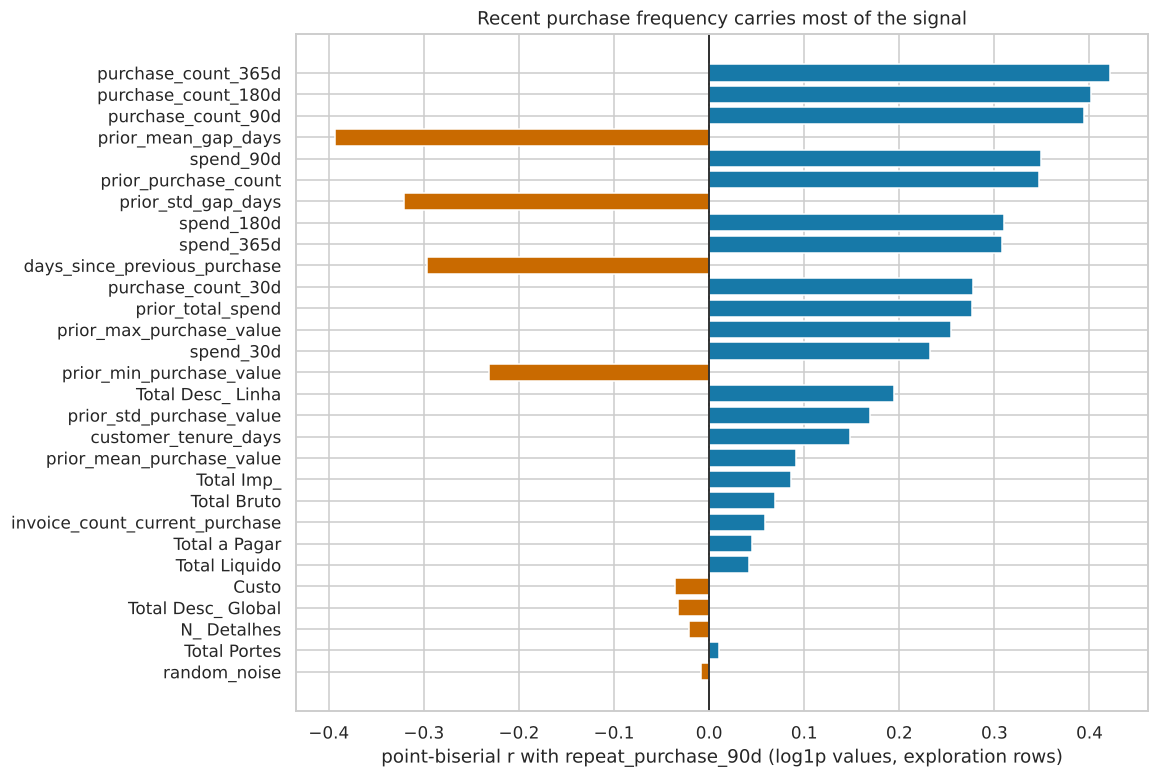

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
plotted = numeric_target["r"].iloc[::-1]
ax.barh(plotted.index, plotted.values,
        color=[PLOT_BLUE if value >= 0 else PLOT_ORANGE for value in plotted.values])
ax.axvline(0, color="black", lw=1)
ax.set(xlabel="point-biserial r with repeat_purchase_90d (log1p values, exploration rows)",
       title="Recent purchase frequency carries most of the signal")
plt.show()

**How often the customer has bought recently is the strongest signal, and what
is in the basket is almost none.**

- The purchase counts over the last 365, 180 and 90 days lead (r = 0.42, 0.40,
  0.40). A purchase followed by a repeat comes from a customer with a median of
  5 purchases in the last year, against 2.
- The gap columns point the other way (`prior_mean_gap_days` r = −0.39,
  `days_since_previous_purchase` r = −0.30): the median time since the previous
  purchase is 37 days before a repeat and 104 days otherwise.
- The current purchase barely matters: `Total a Pagar` r = 0.05,
  `N_ Detalhes` −0.02, `Total Portes` 0.01. Only the line discount stands out
  (r = 0.19).
- **`random_noise` has r = −0.008 (p = 0.56).** It carries no information about
  the label, in line with its name.

In short, the label depends on who is buying and how regularly, far more than
on what was bought this time.

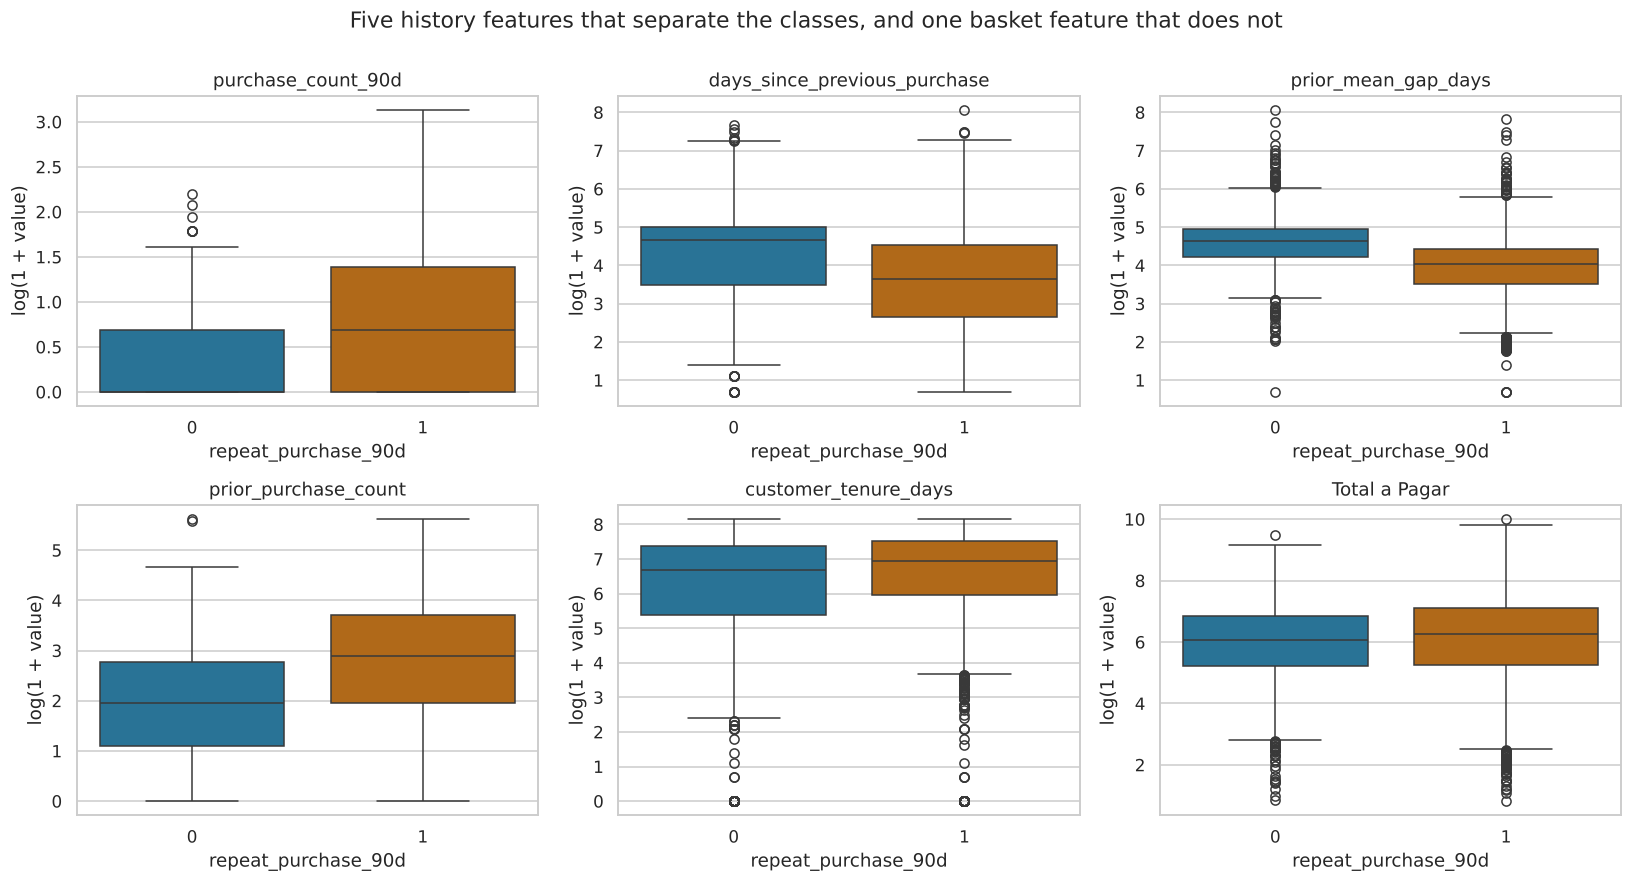

In [36]:
top_six = ["purchase_count_90d", "days_since_previous_purchase", "prior_mean_gap_days",
           "prior_purchase_count", "customer_tenure_days", "Total a Pagar"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), top_six):
    sns.boxplot(x=view[TARGET], y=np.log1p(view[column]), hue=view[TARGET], legend=False,
                palette=[PLOT_BLUE, PLOT_ORANGE], ax=ax)
    ax.set(title=column, xlabel=TARGET, ylabel="log(1 + value)")
plt.suptitle("Five history features that separate the classes, and one basket feature that does not", y=1.0)
plt.tight_layout()
plt.show()

The boxes of the five history features are clearly shifted between the classes,
while those of `Total a Pagar` overlap almost completely. The classes also
overlap on every single feature, so no one column separates them alone.

__Step 23:__ Read the strongest relationship as a rate.

days_since_previous_purchase      0-7     8-14    15-30    31-60    61-90    91-180  181-365     366+  first purchase  unknown
rows                          572.000  450.000  635.000  669.000  450.000  1130.000  441.000  192.000         473.000  163.000
repeat rate                     0.792    0.731    0.655    0.691    0.651     0.412    0.392    0.292           0.334    0.564


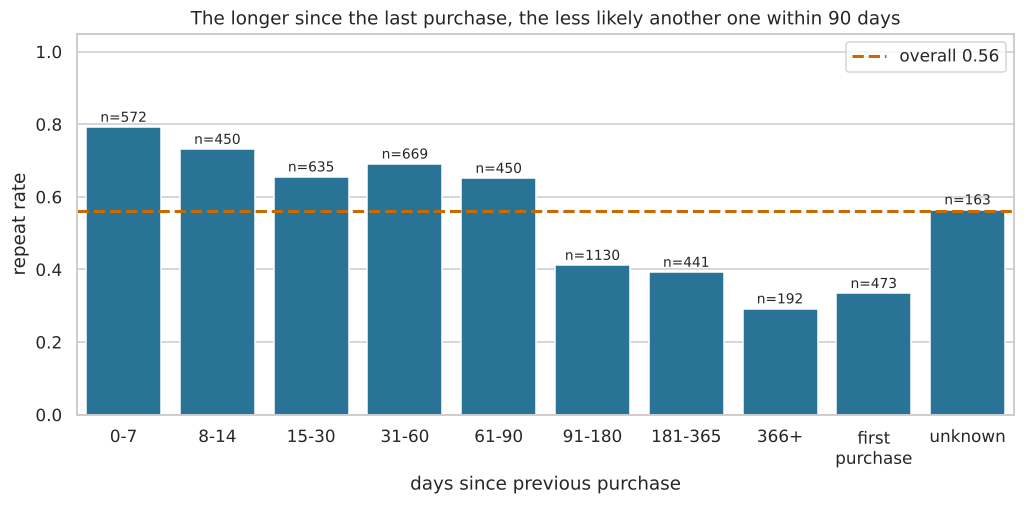

In [37]:
# The same relationship as a rate: repeat rate by time since the previous
# purchase, with first-time buyers as their own group.
recency = pd.cut(view["days_since_previous_purchase"], [-1, 7, 14, 30, 60, 90, 180, 365, np.inf],
                 labels=["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "366+"])
recency = recency.cat.add_categories(["first purchase", "unknown"])
recency[view["prior_purchase_count"] == 0] = "first purchase"
recency = recency.fillna("unknown")
by_recency = view.groupby(recency, observed=True)[TARGET].agg(["size", "mean"])

fig, ax = plt.subplots(figsize=FIGSIZE)
tick_labels = [str(label).replace("first purchase", "first\npurchase") for label in by_recency.index]
sns.barplot(x=tick_labels, y=by_recency["mean"].values, color=PLOT_BLUE, ax=ax)
ax.axhline(view[TARGET].mean(), color=PLOT_ORANGE, ls="--", lw=2,
           label=f"overall {view[TARGET].mean():.2f}")
for position, (rate_value, size) in enumerate(zip(by_recency["mean"], by_recency["size"])):
    ax.text(position, rate_value + 0.015, f"n={size}", ha="center", fontsize=9)
ax.set(xlabel="days since previous purchase", ylabel="repeat rate", ylim=(0, 1.05),
       title="The longer since the last purchase, the less likely another one within 90 days")
ax.legend()
plt.show()

print(by_recency.rename(columns={"size": "rows", "mean": "repeat rate"}).round(3).T.to_string())

**The repeat rate falls from 0.79 to 0.29 as the time since the previous
purchase grows**, with the clearest drop at 90 days: 0.65 to 0.79 below it and
0.41 or less above. A customer who has not bought for more than 90 days is
unlikely to buy within the next 90.

**First purchases repeat in only 33% of cases**, well under the overall 0.56.
These are the rows where the history columns are missing by construction, which
confirms that this kind of missing value is itself a signal.

The "unknown" group (the scattered 3%) sits at the overall rate, 0.56, as
expected if those values are missing at random.

__Step 24:__ Two features at once. Does frequency still matter once recency is
fixed?

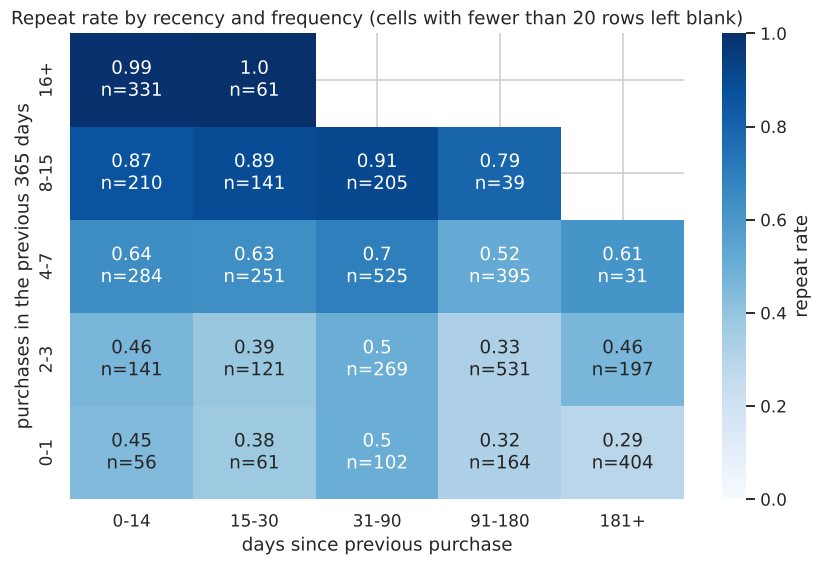

In [38]:
# Two features at once: does frequency still matter once recency is fixed?
recency_band = pd.cut(view["days_since_previous_purchase"], [-1, 14, 30, 90, 180, np.inf],
                      labels=["0-14", "15-30", "31-90", "91-180", "181+"])
frequency_band = pd.cut(view["purchase_count_365d"], [-1, 1, 3, 7, 15, np.inf],
                        labels=["0-1", "2-3", "4-7", "8-15", "16+"])
rate_grid = view.pivot_table(index=frequency_band, columns=recency_band, values=TARGET,
                             aggfunc="mean", observed=False)
size_grid = view.pivot_table(index=frequency_band, columns=recency_band, values=TARGET,
                             aggfunc="size", observed=False)
# A rate over a handful of rows is not a rate worth reading.
labels = rate_grid.round(2).astype(str) + "\nn=" + size_grid.astype(str)
labels = labels.where(size_grid >= 20, "")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(rate_grid.where(size_grid >= 20), annot=labels, fmt="", cmap="Blues",
            vmin=0, vmax=1, cbar_kws={"label": "repeat rate"}, ax=ax)
ax.invert_yaxis()
ax.set(xlabel="days since previous purchase", ylabel="purchases in the previous 365 days",
       title="Repeat rate by recency and frequency (cells with fewer than 20 rows left blank)")
plt.show()

**Frequency dominates, and recency adds little once frequency is known.**
Reading up any column, the repeat rate climbs from about 0.3 to 0.5 for
customers with at most 3 purchases in the last year to between 0.8 and 1.0
for those with 8 or more. Reading along a row it changes far less: customers with
4 to 7 purchases repeat at 0.52 to 0.70 whatever the time since the last one.

The two features are also strongly tied: frequent buyers are almost never
found at long gaps (the empty corner). So much of the recency effect seen in
the previous plot is frequency seen from another side, which matters for
feature selection.

__Step 25:__ Categorical features against the label, measured with
**Cramér's V**.

In [39]:
# Categorical feature against a binary label: Cramer's V, with the smallest
# expected count beside it, because a table with near-empty cells makes the
# chi-square p-value unreliable.
rows = []
for column in categorical:
    table = pd.crosstab(view[column], view[TARGET])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[0], "chi2": chi2,
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
pd.DataFrame(rows).set_index("feature").sort_values("Cramer's V", ascending=False).round(4)

,levels,chi2,Cramer's V,p,min expected count
feature,,,,,
transport_method,77,431.0033,0.2929,0.0000,0.4402
payment_type,9,308.1144,0.2478,0.0000,0.8804
salesperson,9,222.2139,0.2101,0.0000,1.3251
commercial_zone,5,22.4841,0.0659,0.0002,0.4402
warehouse,2,1.6998,0.0184,0.1923,7.0863
document_series,3,0.3771,0.0085,0.8281,637.8400


In [40]:
for column in ["payment_type", "salesperson", "document_series"]:
    by_level = (view.groupby(view[column].fillna("(missing)"))[TARGET]
                .agg(rows="size", repeat_rate="mean")
                .sort_values("rows", ascending=False))
    print(by_level.round(3).to_string(), "\n")

                           rows  repeat_rate
payment_type                                
Maybe Tomorrow Payment 7   3626        0.526
Maybe Tomorrow Payment 12   804        0.537
Maybe Tomorrow Payment 9    413        0.959
(missing)                   157        0.561
Maybe Tomorrow Payment 10   110        0.391
Maybe Tomorrow Payment 8     35        0.314
Maybe Tomorrow Payment 2     16        0.625
Maybe Tomorrow Payment 4      7        0.429
Maybe Tomorrow Payment 11     5        0.800
Maybe Tomorrow Payment 3      2        0.500 

                  rows  repeat_rate
salesperson                        
VLOOKUP Master 1  3233        0.627
VLOOKUP Master 4  1183        0.391
VLOOKUP Master 9   307        0.550
VLOOKUP Master 7   169        0.473
(missing)          142        0.613
VLOOKUP Master 2    95        0.589
VLOOKUP Master 3    24        0.417
VLOOKUP Master 6    12        0.000
VLOOKUP Master 5     7        0.429
VLOOKUP Master 8     3        1.000 

                 rows  r

**Three categorical columns are associated with the label**: `transport_method`
(V = 0.29), `payment_type` (0.25) and `salesperson` (0.21). `document_series`
(0.01) and `warehouse` (0.02) are not, and `commercial_zone` is weak (0.07).

The rates show where the association comes from. One payment type has a repeat
rate of 0.96 on 413 rows, against 0.53 for the most common one. The two main
salespeople differ too (0.63 against 0.39).

The four tables with rare levels (`transport_method`, `payment_type`,
`salesperson`, `commercial_zone`) have expected counts below 5, so their
p-values are indicative only, and the rates of levels
with a handful of rows (a salesperson at 0.00 on 12 rows) should not be read
as findings.

__Step 26:__ Before trusting those associations, ask how much of each
categorical column is simply the customer.

In [41]:
# How much of each categorical column is decided by who the customer is?
# Share of rows that sit on their own customer's most common level.
per_customer_rows = filled.groupby("customer_id").size()
rows = {}
for column in categorical:
    modal_share = filled.groupby("customer_id")[column].agg(
        lambda values: values.value_counts(normalize=True).iloc[0] if values.notna().any() else np.nan)
    known = modal_share.notna()
    rows[column] = (modal_share[known] * per_customer_rows[known]).sum() / per_customer_rows[known].sum()
print(pd.Series(rows).sort_values(ascending=False).round(3)
      .to_frame("share of rows on the customer's usual level").to_string())

level_nine = view[view["payment_type"] == "Maybe Tomorrow Payment 9"]
print(f"\n'Maybe Tomorrow Payment 9': {len(level_nine)} exploration rows from"
      f" {level_nine['customer_id'].nunique()} customers;"
      f" the two largest hold {level_nine['customer_id'].value_counts().iloc[:2].sum()} of them")

                  share of rows on the customer's usual level
commercial_zone                                         0.999
warehouse                                               0.997
payment_type                                            0.963
salesperson                                             0.917
transport_method                                        0.751
document_series                                         0.597

'Maybe Tomorrow Payment 9': 413 exploration rows from 6 customers; the two largest hold 334 of them


<div class="alert alert-block alert-warning">

**The categorical columns largely describe the customer, not the purchase.**
96% of rows carry their customer's usual `payment_type`, 92% their usual
`salesperson`, and `commercial_zone` is fixed per customer.

The payment type with a 0.96 repeat rate is 413 rows from 6 customers, and two
very active customers hold 334 of them. That column is not showing that a
payment method causes repeat purchases; it is identifying two customers who
buy constantly. The associations above are real for prediction, but they are
partly customer identity in another form and must be judged on customers the
model has not seen.

</div>

__Step 27:__ The identifiers themselves, treated critically.

In [42]:
# The identifier, treated as what it is: does WHO the customer is carry the label?
customer_rate = view.groupby("customer_id")[TARGET].agg(rows="size", repeat_rate="mean")
activity = pd.cut(customer_rate["rows"], [0, 1, 4, 12, 40, np.inf],
                  labels=["1", "2-4", "5-12", "13-40", "41+"])
print("exploration rows per customer -> customers, and their mean repeat rate")
print(customer_rate.groupby(activity, observed=True)
      .agg(customers=("rows", "size"), rows=("rows", "sum"), repeat_rate=("repeat_rate", "mean"))
      .round(3).to_string())

r, p = pointbiserialr(view[TARGET], view["customer_id"])
print(f"\ncustomer_id as a NUMBER against the label: r = {r:+.3f} (p = {p:.1e})")
r, p = pointbiserialr(view[TARGET], view.index)
print(f"ID (row index) as a number against the label: r = {r:+.3f} (p = {p:.2f})")

exploration rows per customer -> customers, and their mean repeat rate
       customers  rows  repeat_rate
rows                               
1            154   154        0.032
2-4          183   488        0.254
5-12         120   952        0.398
13-40         95  2037        0.474
41+           24  1544        0.831

customer_id as a NUMBER against the label: r = -0.120 (p = 5.1e-18)
ID (row index) as a number against the label: r = +0.018 (p = 0.20)


**The customer explains a great deal of the label, and that is why
`customer_id` must not be a feature.**

- Customers with one row repeat in 3% of cases; customers with more than 40
  rows in 83%. But the number of rows a customer has in the file counts
  purchases made *after* the one being predicted, so it is known only in
  hindsight. `prior_purchase_count` and the window counts are the legitimate
  versions of the same idea, because they stop at the purchase date.
- **Read as a number, `customer_id` correlates with the label at r = −0.12.**
  An id has no magnitude, so this is an artefact of which ids the large
  customers happen to have. A model given the column would learn individual
  customers, which cannot transfer to a new customer.
- **`ID` has r = +0.018 (p = 0.20)**: no relation, as a row label should.

`customer_id` is therefore kept only as the key for joining `clientes.csv` and
for grouping rows, never as an input.

__Step 28:__ Feature against feature. Which columns say the same thing?

7 feature pairs with |rho| >= 0.90:
Total a Pagar             Total Liquido               1.000
Total Bruto               Total Liquido               0.991
Total a Pagar             Total Bruto                 0.991
purchase_count_30d        spend_30d                   0.966
prior_std_purchase_value  prior_max_purchase_value    0.935
purchase_count_90d        spend_90d                   0.909
prior_purchase_count      prior_total_spend           0.902


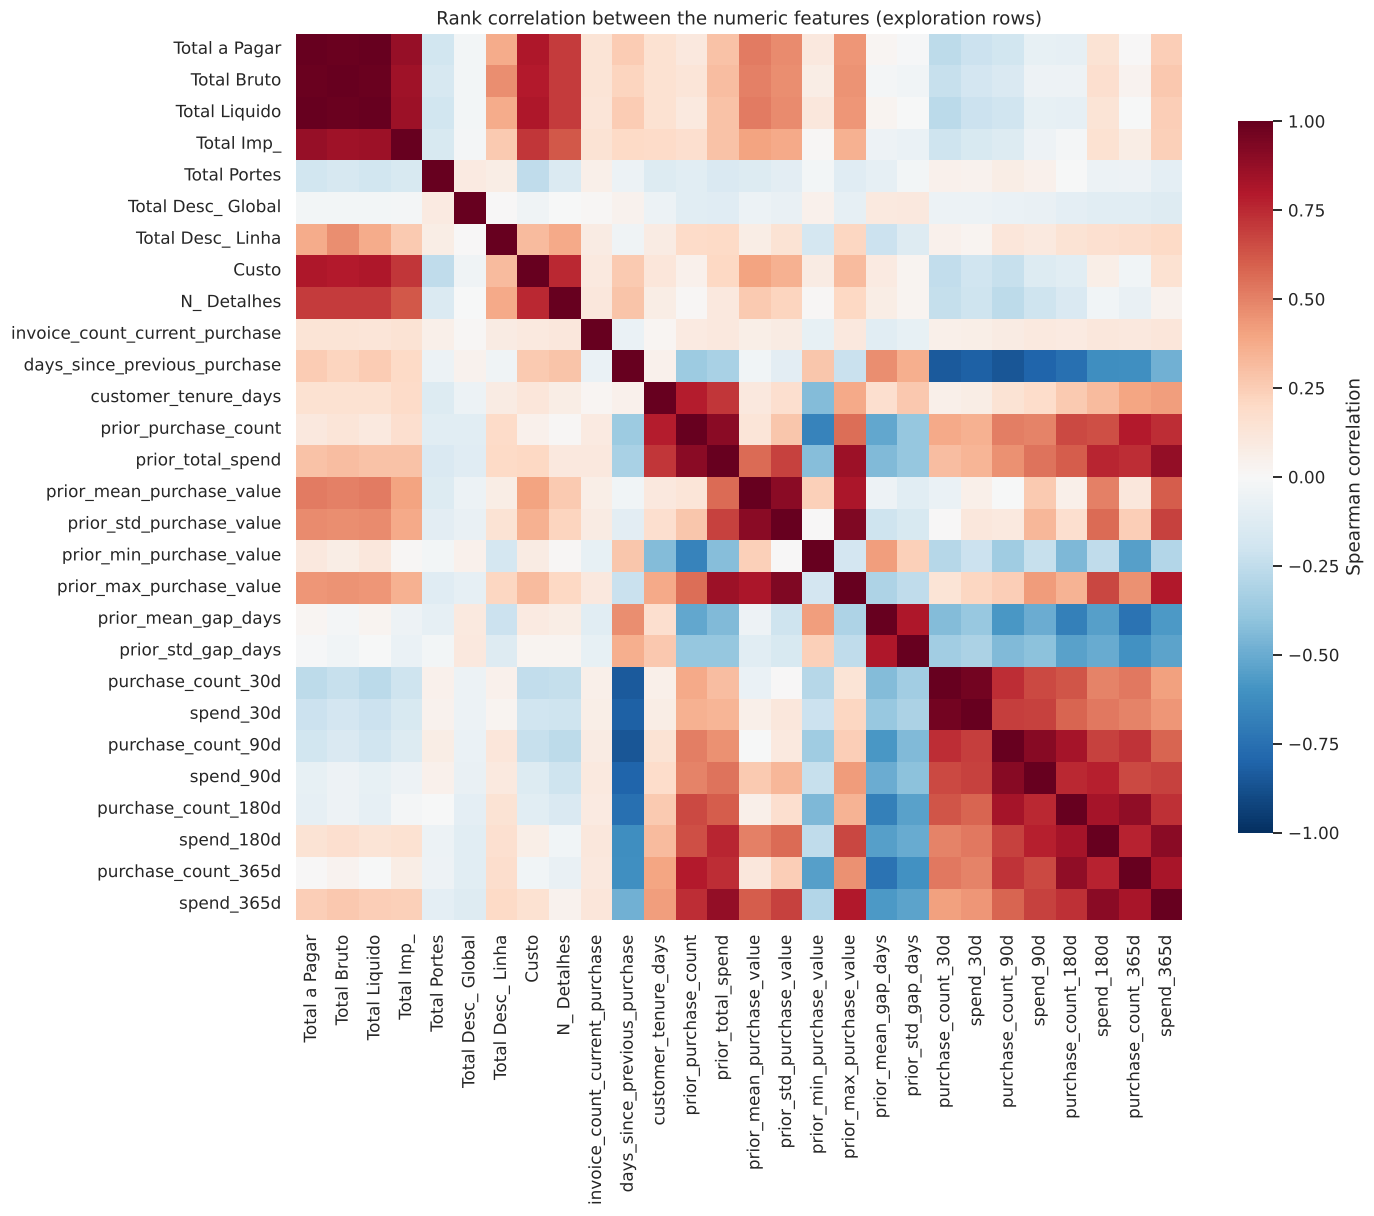

In [43]:
# Feature against feature. Spearman, because it reads ranks and so is not
# moved by the long tails.
correlation = view[numeric].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10.5))
sns.heatmap(correlation, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={"label": "Spearman correlation", "shrink": 0.8}, ax=ax)
ax.set(title="Rank correlation between the numeric features (exploration rows)")
plt.show()

upper = correlation.where(np.triu(np.ones(correlation.shape, dtype=bool), k=1)).stack()
strong = upper[upper.abs() >= 0.90].sort_values(key=abs, ascending=False)
print(f"{len(strong)} feature pairs with |rho| >= 0.90:")
print(strong.round(3).to_string())

**The features come in blocks that move together**, visible as the dark squares
on the diagonal: the invoice amounts, the window counts and spends, and the
gap columns. Seven pairs reach |ρ| ≥ 0.90.

- `Total a Pagar`, `Total Bruto` and `Total Liquido` are near copies of each
  other (ρ = 0.99 to 1.00), as the identities in Section 1.8 imply.
- Each window's count and spend rise together (ρ = 0.97 at 30 days, 0.91 at
  90), as do `prior_purchase_count` and `prior_total_spend` (0.90).
- `prior_std_purchase_value` follows `prior_max_purchase_value` (0.94).

Redundant columns do not add information and make coefficients unstable, so
each block is a candidate for keeping one representative. That choice is made
with the feature-selection methods in Section 3.

__Step 29:__ Does `clientes.csv` add signal? Join it to the exploration rows and
measure.

In [44]:
# clientes.csv joined to the exploration rows on customer_id. A left join, so
# no purchase row is added or lost.
joined = view.merge(clientes, on="customer_id", how="left", validate="many_to_one")
assert len(joined) == len(view)

rows = []
for column in ["country_or_region", "commercial_region", "island", "customer_since_year"]:
    table = pd.crosstab(joined[column].fillna("(missing)"), joined[TARGET])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[0],
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
print(pd.DataFrame(rows).set_index("feature").round(4).to_string())

print("\nrepeat rate by customer_since_year (exploration rows):")
print(joined.groupby("customer_since_year")[TARGET].agg(rows="size", repeat_rate="mean")
      .round(3).T.to_string())

                     levels  Cramer's V       p  min expected count
feature                                                            
country_or_region         6      0.0678  0.0002              0.4402
commercial_region        32      0.2714  0.0000              0.4402
island                   11      0.1395  0.0000              3.9617
customer_since_year      10      0.1959  0.0000              7.9235

repeat rate by customer_since_year (exploration rows):
customer_since_year      2015     2016     2017     2018     2019     2020     2021    2022   2023    2024
rows                 2812.000  483.000  715.000  368.000  228.000  216.000  157.000  86.000  92.00  18.000
repeat_rate             0.596    0.559    0.669    0.348    0.439    0.477    0.344   0.279   0.62   0.333


**The customer table carries some signal, concentrated in
`commercial_region`** (V = 0.27), followed by `customer_since_year` (0.20) and
`island` (0.14); `country_or_region` is weak (0.07).

Two cautions. These columns are constant per customer, so like the
categorical columns above they partly identify the large customers, and
`commercial_region` has 32 levels with expected counts below 1. And
`customer_since_year` shows no steady pattern across years (0.60 for 2015,
0.35 for 2018, 0.62 for 2023), with few rows in the later years.

Whether and how to integrate the table is decided in Section 2. The evidence
here supports at most a few coarse columns and argues against the address-level
ones.

## <font color='#E8800A'>1.12 · What the exploration found</font> <a class="anchor" id="findings"></a>
[Back to TOC](#toc)

Nothing above changed a cell of `train` or `clientes`. What the section leaves
is a list of findings, each with the decision it hands to the next sections.

<div class="alert alert-block alert-info">

| # | what the exploration found | what is still open |
|---|---|---|
| 1 | One row is one purchase; 6,534 rows, 610 customers, and the top 10% of customers hold 50.4% of rows. The label is exactly "next purchase within 90 days". | How to split for assessment so that the same customer does not flatter the score (Section 4). |
| 2 | Classes are 55.92% / 44.08%; always answering "repeat" scores 0.5592. | Which metric to report beside accuracy (Section 4). |
| 3 | 65 rows (0.99%) have no features at all; 16 of them are exact duplicates. | Drop them from training? What to predict for such a row if `test.csv` has one (Section 2). |
| 4 | 5,921 missing cells are history statistics that do not exist yet (first or second purchase). First purchases repeat at 0.33 against 0.56 overall. | Fill value and whether to add a "new customer" indicator (Section 2). |
| 5 | 1,557 missing cells are scattered at about 3% in eight columns, unrelated to the label. | Which fill, fitted on training rows only; the mean can be recomputed exactly (Section 2). |
| 6 | 224 impossible cells on 223 rows: placeholders (1,000,000,000 and −4), flipped signs, and inflated values caught by cross-column rules. | Repair where the value can be rebuilt, blank otherwise (Section 2). |
| 7 | All numeric columns but tenure are right-skewed (skew 2 to 27), several are mostly zero, and the IQR rule would flag 66.5% of rows. | A transformation such as `log1p` and scaling, not row removal (Section 2). |
| 8 | `transport_method` has 80 levels, 40 under 10 rows; `warehouse` and `commercial_zone` are 99.7% and 96.8% one level. | Grouping rare levels, encoding, and dropping near-constant columns (Sections 2 and 3). |
| 9 | Signal sits in purchase frequency and recency (r up to 0.42); the basket columns carry almost none. Seven feature pairs have ρ ≥ 0.90. | Which representative of each redundant block to keep (Section 3). |
| 10 | `random_noise` (r = −0.008) and `ID` (r = +0.018) are unrelated to the label; `customer_id` is an identifier whose numeric value correlates by artefact (r = −0.12). | Exclude all three as features; `customer_id` stays as join and grouping key (Section 3). |
| 11 | `clientes.csv` joins cleanly on `customer_id` (unique, 610 of 610 covered). `customer_type` is empty, the address-level columns are identifiers, 58% of `customer_since_year` is the 2015 floor. | Integrate a few coarse columns (`commercial_region`, `island`) or none (Section 2). |

</div>